# Data Mining Course Project
## HR Analytics Dataset 

**Dataset:** `hr_data_mining_dataset
`
**Pipeline order:** GA → K-Medoid Clustering → Hierarchical Clustering → Fuzzy Logic


## Setup

In [126]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE = "Set2"

NUMERIC_COLS   = ["age", "experience_years", "salary",
                  "attendance_rate", "projects_completed",
                  "overtime_hours", "performance_score"]


CATEGORIC_COLS = ["department", "education_level"]

In [ ]:
df = pd.read_csv("C:/Users/Omar/Downloads/hr_data_mining_dataset.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (1515, 9)


,age,experience_years,salary,attendance_rate,projects_completed,overtime_hours,department,education_level,performance_score
0,59,15,22193.0,75.28,28,103.0,HR,PhD,47.297374
1,49,26,7167.0,57.20,41,117.0,IT,High School,64.760494
2,35,7,15989.0,81.20,11,32.0,Operations,Bachelor,30.870878
3,28,6,26736.0,63.68,13,71.0,HR,Bachelor,38.241157
4,41,16,29393.0,74.39,47,87.0,Marketing,Bachelor,71.364698


In [128]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1515.0,NaN,NaN,NaN,40.708911,11.630445,21.0,31.0,41.0,50.0,83.0
experience_years,1515.0,NaN,NaN,NaN,11.557096,9.146316,0.0,4.0,9.0,18.0,34.0
salary,1452.0,NaN,NaN,NaN,19284.5427,20574.324625,4025.0,10348.75,17284.5,24085.5,264490.0
attendance_rate,1471.0,NaN,NaN,NaN,74.986152,14.634791,50.0,62.345,74.64,87.44,114.890962
projects_completed,1515.0,NaN,NaN,NaN,24.362376,14.487777,0.0,12.0,25.0,37.0,49.0
overtime_hours,1485.0,NaN,NaN,NaN,62.600673,41.859814,0.0,30.0,62.0,92.0,349.0
department,1515,20,HR,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,1484,15,PhD,379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
performance_score,1515.0,NaN,NaN,NaN,49.599808,19.412077,0.0,34.900609,49.797801,63.56439,100.0


---
## 2. Task 1 — Exploratory Data Analysis



###  Missing Values





In [129]:
# --- Missing value counts per column ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
display(missing_df[missing_df["Missing Count"] > 0])

,Missing Count,Missing %
salary,63,4.16
attendance_rate,44,2.90
overtime_hours,30,1.98
education_level,31,2.05


### Diagnostic 2 — Categorical Inconsistencies

**What we check:** The actual unique values in `department` and `education_level`. Clean data should have exactly **5** and **4** canonical values respectively.

## Each typo variant (`'hr'`, `'Financee'`, `'Phd'`, `'Bachelors'`) is treated as a separate category during encoding. 


In [130]:
# --- Department unique values ---
dept_vals = df["department"].value_counts()
valid_depts = {"HR", "IT", "Finance", "Operations", "Marketing"}
invalid_dept = dept_vals[~dept_vals.index.isin(valid_depts)]
print(f"department — {df['department'].nunique()} unique values (expected 5):")
print(f"  Valid   ({len(dept_vals[dept_vals.index.isin(valid_depts)])}): {sorted(valid_depts)}")
print(f"  Invalid ({len(invalid_dept)}): {sorted(invalid_dept.index.tolist())}")

print()

# --- Education unique values ---
edu_vals = df["education_level"].value_counts()
valid_edu = {"High School", "Bachelor", "Master", "PhD"}
invalid_edu = edu_vals[~edu_vals.index.isin(valid_edu)]
print(f"education_level — {df['education_level'].nunique()} unique values (expected 4):")
print(f"  Valid   ({len(edu_vals[edu_vals.index.isin(valid_edu)])}): {sorted(valid_edu)}")
print(f"  Invalid ({len(invalid_edu)}): {sorted(invalid_edu.index.tolist())}")
print(f"\n→ {len(invalid_dept) + len(invalid_edu)} invalid category variants must be standardised before encoding.")

department — 20 unique values (expected 5):
  Valid   (5): ['Finance', 'HR', 'IT', 'Marketing', 'Operations']
  Invalid (15): ['FINANCE', 'Financee', 'H.R', 'Hr', 'I.T', 'It', 'MARKETING', 'Marketting', 'OPERATIONS', 'Ops', 'finance', 'hr', 'it', 'marketing', 'operations']

education_level — 15 unique values (expected 4):
  Valid   (4): ['Bachelor', 'High School', 'Master', 'PhD']
  Invalid (11): ['BACHELOR', 'Bachelors', 'HIGH SCHOOL', 'Highschool', 'MASTER', 'PHD', 'Ph.D', 'Phd', 'bachelor', 'high school', 'master']

→ 26 invalid category variants must be standardised before encoding.


###  Outlier Detection

**What we check:** For each numeric feature, values falling outside the 1.5×IQR fences — and the magnitude of those values to confirm they are data errors rather than rare but valid observations.



In [131]:
report = {}
for col in NUMERIC_COLS:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[col] < lo) | (df[col] > hi)][col]
    report[col] = {
        "Lower Fence": round(lo, 2),
        "Upper Fence": round(hi, 2),
        "Outlier Count": len(outliers),
        "Min Outlier": round(outliers.min(), 2) if len(outliers) else "-",
        "Max Outlier": round(outliers.max(), 2) if len(outliers) else "-",
    }

display(pd.DataFrame(report).T)
total_out = sum(v["Outlier Count"] for v in report.values())
print(f"\nTotal outlier values: {total_out}")
print("→ salary, overtime_hours, attendance_rate, and age contain erroneous extremes requiring winsorization.")

,Lower Fence,Upper Fence,Outlier Count,Min Outlier,Max Outlier
age,2.5,78.5,4.0,80.0,83.0
experience_years,-17.0,39.0,0,-,-
salary,-10256.38,44690.62,21.0,59140.0,264490.0
attendance_rate,24.7,125.08,0,-,-
projects_completed,-25.5,74.5,0,-,-
overtime_hours,-63.0,185.0,15.0,214.0,349.0
performance_score,-8.1,106.56,0,-,-



Total outlier values: 40
→ salary, overtime_hours, attendance_rate, and age contain erroneous extremes requiring winsorization.


###  Duplicate Rows

**What we check:** Exact duplicate records — same values across all 9 columns.



In [132]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes}  ({n_dupes/len(df)*100:.1f}% of dataset)")
print()
print("Sample of duplicated records:")
display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(4))
print(f"\n→ {n_dupes} rows will be dropped in Step 2 of preprocessing.")

Duplicate rows: 9  (0.6% of dataset)

Sample of duplicated records:


,age,experience_years,salary,attendance_rate,projects_completed,overtime_hours,department,education_level,performance_score
1096,40,8,20386.0,58.44,34,42.0,IT,Bachelor,50.304722
1513,40,8,20386.0,58.44,34,42.0,IT,Bachelor,50.304722
667,41,11,7765.0,65.39,42,78.0,Finance,High School,59.859315
1501,41,11,7765.0,65.39,42,78.0,Finance,High School,59.859315



→ 9 rows will be dropped in Step 2 of preprocessing.


---
## 3. Task 2 — Data Preprocessing

### Data Cleaning

Steps 1–4 address the raw data quality issues identified in the diagnostics above.
Each step is applied sequentially so later steps operate on already-cleaned data.

| Diagnostic finding | Step |
|---|---|
| 168 missing values | Step 1 — Imputation |
| 9 duplicate rows | Step 2 — Deduplication |
| 82 categorical typos | Step 3 — Standardisation |
| 40 numeric outliers | Step 4 — Winsorization |


### Step 1 — Missing Value Check & Imputation

In [133]:
df_proc = df.copy()

missing = df_proc.isnull().sum().rename("Missing Count").to_frame()
missing["Missing %"] = (missing["Missing Count"] / len(df_proc) * 100).round(2)
display(missing[missing["Missing Count"] > 0])

,Missing Count,Missing %
salary,63,4.16
attendance_rate,44,2.90
overtime_hours,30,1.98
education_level,31,2.05


**Missing values found in 4 columns** (168 total):

| Column | Count | % | Strategy | Justification |
|---|---|---|---|---|
| `salary` | 63 | 4.2% | Median imputation | Right-skewed after outlier inflation; median is robust to extremes |
| `attendance_rate` | 44 | 2.9% | Median imputation | Bounded continuous variable; median preserves central tendency |
| `overtime_hours` | 30 | 2.0% | Median imputation | Right-skewed distribution; median avoids pulling imputed values toward outliers |
| `education_level` | 31 | 2.0% | Mode imputation | Categorical; mode assigns the most common credential, minimising distortion |

**MCAR confirmed:** Co-occurrence matrix showed only 8 rows with 2+ columns missing simultaneously out of 160 affected rows — missingness is independent across columns. Per-column imputation is safe; no rows need to be dropped.


In [134]:
# Numeric columns: impute with median (robust to skew and outliers)
for col in ["salary", "attendance_rate", "overtime_hours"]:
    median_val = df_proc[col].median()
    df_proc[col] = df_proc[col].fillna(median_val)
    print(f"{col}: imputed {df[col].isnull().sum()} NaNs with median={median_val:.2f}")

# Categorical column: impute with mode
edu_mode = df_proc["education_level"].mode()[0]
df_proc["education_level"] = df_proc["education_level"].fillna(edu_mode)
print(f"education_level: imputed {df['education_level'].isnull().sum()} NaNs with mode='{edu_mode}'")

print(f"\nRemaining NaNs: {df_proc.isnull().sum().sum()}")

salary: imputed 63 NaNs with median=17284.50
attendance_rate: imputed 44 NaNs with median=74.64
overtime_hours: imputed 30 NaNs with median=62.00
education_level: imputed 31 NaNs with mode='PhD'

Remaining NaNs: 0


### Step 2 — Duplicate Row Removal

In [135]:
n_dupes = df_proc.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")
df_proc = df_proc.drop_duplicates().reset_index(drop=True)
print(f"Rows after removal: {len(df_proc)}")

Duplicate rows found: 9
Rows after removal: 1506


**Result:** 9 duplicate rows detected and removed. Dataset reduced from **1,515 → 1,506 rows**.

**Justification:** Duplicate records create artificial density in feature space. K-Medoid selects medoids based on minimum total distance to cluster members — duplicated profiles inflate local density and bias medoid selection toward those records even when the genuine segment is small. All duplicates removed before any distance computation.


### Step 3 — Categorical Standardisation

In [136]:
# Standardise department values
dept_map = {
    "hr": "HR", "H.R": "HR", "Hr": "HR",
    "it": "IT", "I.T": "IT", "It": "IT",
    "finance": "Finance", "Financee": "Finance", "FINANCE": "Finance",
    "operations": "Operations", "Ops": "Operations", "OPERATIONS": "Operations",
    "marketing": "Marketing", "Marketting": "Marketing", "MARKETING": "Marketing",
}
df_proc["department"] = df_proc["department"].replace(dept_map)
print("Department unique values:", sorted(df_proc["department"].unique()))

# Standardise education_level values
edu_map_std = {
    "Phd": "PhD", "PHD": "PhD", "Ph.D": "PhD",
    "master": "Master", "Masters": "Master", "MASTER": "Master",
    "bachelor": "Bachelor", "Bachelors": "Bachelor", "BACHELOR": "Bachelor",
    "high school": "High School", "Highschool": "High School", "HIGH SCHOOL": "High School",
}
df_proc["education_level"] = df_proc["education_level"].replace(edu_map_std)
print("Education unique values:", sorted(df_proc["education_level"].unique()))

Department unique values: ['Finance', 'HR', 'IT', 'Marketing', 'Operations']
Education unique values: ['Bachelor', 'High School', 'Master', 'PhD']


**Result:**  invalid category variants mapped to 5 canonical department values and 4 canonical education values.




### Step 4 — Outlier Detection & Treatment (IQR )

In [137]:
report = {}
for col in NUMERIC_COLS:
    Q1, Q3 = df_proc[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = int(((df_proc[col] < lo) | (df_proc[col] > hi)).sum())
    report[col] = {"Q1": round(Q1,2), "Q3": round(Q3,2), "IQR": round(IQR,2),
                   "Lower Fence": round(lo,2), "Upper Fence": round(hi,2),
                   "Outlier Count": n_out}

display(pd.DataFrame(report).T)

,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count
age,31.00,50.00,19.00,2.50,78.50,4.0
experience_years,4.00,18.00,14.00,-17.00,39.00,0.0
salary,10773.25,23754.50,12981.25,-8698.62,43226.38,21.0
attendance_rate,62.66,86.97,24.31,26.20,123.42,0.0
projects_completed,12.00,37.00,25.00,-25.50,74.50,0.0
overtime_hours,30.00,91.00,61.00,-61.50,182.50,15.0
performance_score,34.88,63.62,28.74,-8.22,106.73,0.0


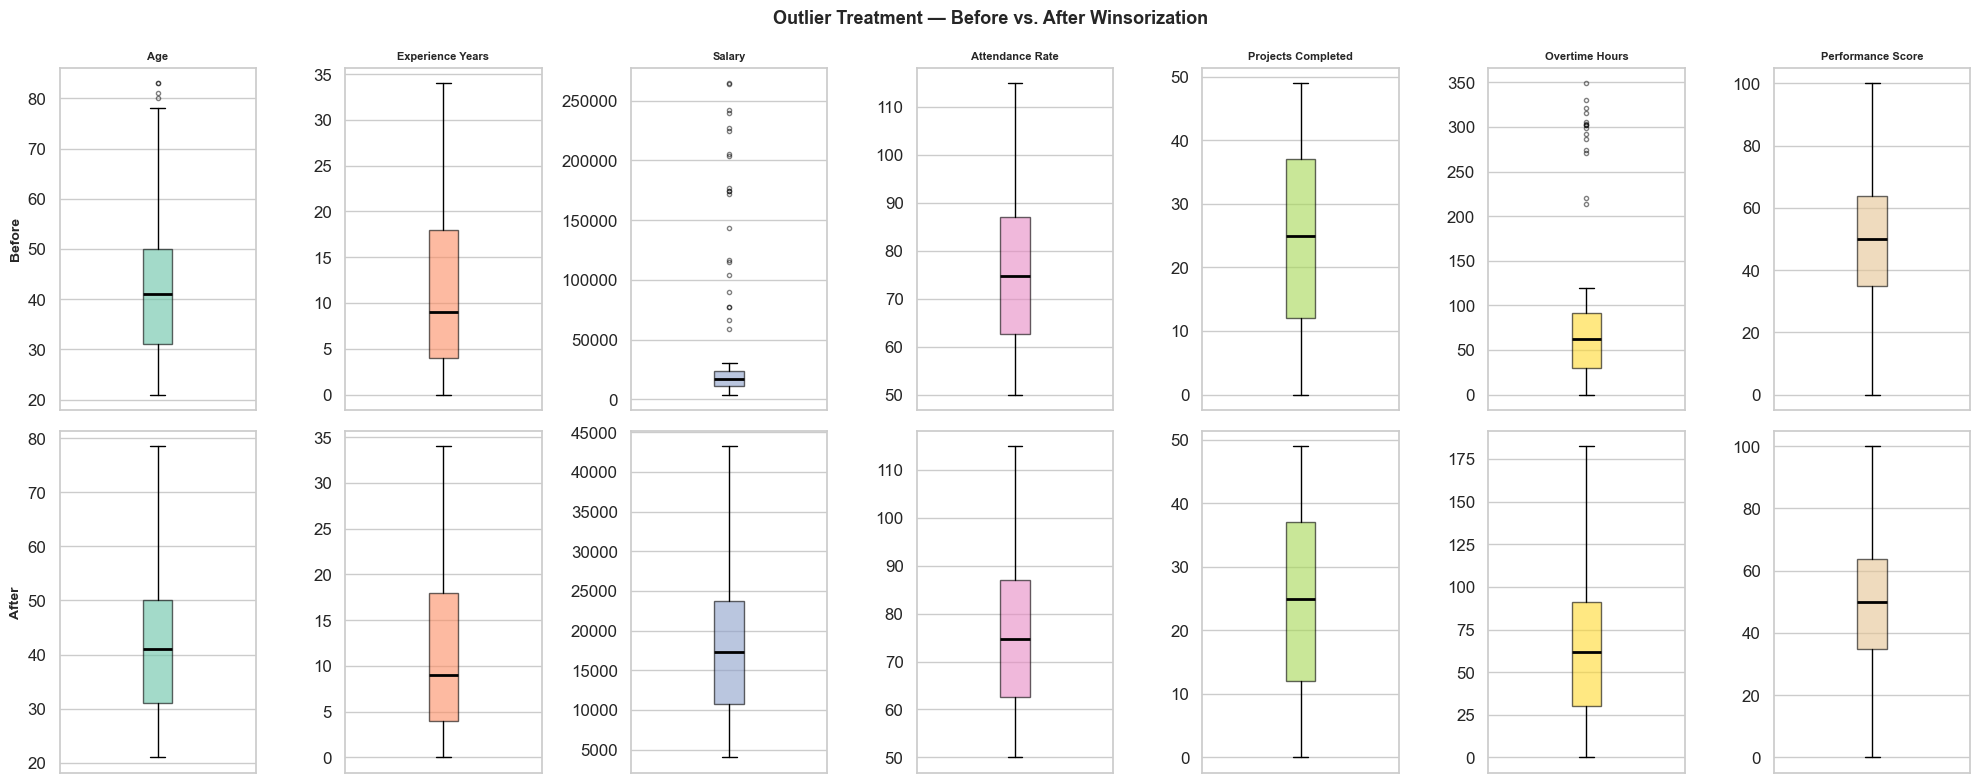

In [138]:
df_before_outlier = df_proc[NUMERIC_COLS].copy()

for col in NUMERIC_COLS:
    Q1, Q3 = df_proc[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    df_proc[col] = df_proc[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

# Before / After comparison
fig, axes = plt.subplots(2, 7, figsize=(20, 8))
colors = sns.color_palette(PALETTE, len(NUMERIC_COLS))

for i, col in enumerate(NUMERIC_COLS):
    # Before
    axes[0, i].boxplot(df_before_outlier[col], patch_artist=True,
                       boxprops=dict(facecolor=colors[i], alpha=0.6),
                       medianprops=dict(color="black", lw=2),
                       flierprops=dict(marker="o", markersize=3, alpha=0.5))
    axes[0, i].set_title(col.replace("_"," ").title(), fontsize=8, fontweight="bold")
    axes[0, i].set_xticks([])

    # After
    axes[1, i].boxplot(df_proc[col], patch_artist=True,
                       boxprops=dict(facecolor=colors[i], alpha=0.6),
                       medianprops=dict(color="black", lw=2),
                       flierprops=dict(marker="o", markersize=3, alpha=0.5))
    axes[1, i].set_xticks([])

axes[0, 0].set_ylabel("Before", fontweight="bold", fontsize=10)
axes[1, 0].set_ylabel("After", fontweight="bold", fontsize=10)
fig.suptitle("Outlier Treatment — Before vs. After Winsorization", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Outliers detected and treated in 3 features** (40 total):



**Justification — Winsorization over row removal:** Removing 40 rows from 1,506 records is unnecessary. Capping at the IQR fence corrects the erroneous value while retaining the employee record — all 1,506 rows are preserved for clustering.


---
### Part B — Clean Data Visualizations

The dataset is now clean (imputed, deduplicated, standardised, outliers treated).
The following four plots provide the insights that drive GA, clustering, and Fuzzy Logic decisions.


In [139]:

# Recover original-scale numeric columns by inverse-transforming for EDA readability
# (We read the pre-scale version from df_proc state — reconstruct from dirty + preprocessing steps)
# For EDA we use df_proc at the post-imputation/dedup/standardise/outlier stage
# That state is already captured in df_proc before encoding — we'll reload from scratch cleanly

df_clean_eda = pd.read_csv("hr_data_mining_dataset_dirty.csv")

# Step 1: impute
for col in ["salary", "attendance_rate", "overtime_hours"]:
    df_clean_eda[col] = df_clean_eda[col].fillna(df_clean_eda[col].median())
df_clean_eda["education_level"] = df_clean_eda["education_level"].fillna(
    df_clean_eda["education_level"].mode()[0])

# Step 2: dedup
df_clean_eda = df_clean_eda.drop_duplicates().reset_index(drop=True)

# Step 3: standardise categories
dept_map = {
    "hr":"HR","H.R":"HR","Hr":"HR",
    "it":"IT","I.T":"IT","It":"IT",
    "finance":"Finance","Financee":"Finance","FINANCE":"Finance",
    "operations":"Operations","Ops":"Operations","OPERATIONS":"Operations",
    "marketing":"Marketing","Marketting":"Marketing","MARKETING":"Marketing",
}
edu_map_std = {
    "Phd":"PhD","PHD":"PhD","Ph.D":"PhD",
    "master":"Master","Masters":"Master","MASTER":"Master",
    "bachelor":"Bachelor","Bachelors":"Bachelor","BACHELOR":"Bachelor",
    "high school":"High School","Highschool":"High School","HIGH SCHOOL":"High School",
}
df_clean_eda["department"]     = df_clean_eda["department"].replace(dept_map)
df_clean_eda["education_level"] = df_clean_eda["education_level"].replace(edu_map_std)

# Step 4: winsorise outliers
NUMERIC_COLS = ["age","experience_years","salary","attendance_rate",
                "projects_completed","overtime_hours","performance_score"]
for col in NUMERIC_COLS:
    Q1, Q3 = df_clean_eda[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    df_clean_eda[col] = df_clean_eda[col].clip(lower=Q1-1.5*IQR, upper=Q3+1.5*IQR)

print(f"Clean EDA dataset: {df_clean_eda.shape}")
print(f"Department values: {sorted(df_clean_eda['department'].unique())}")

Clean EDA dataset: (1506, 9)
Department values: ['Finance', 'HR', 'IT', 'Marketing', 'Operations']


### Plot 1 — Distribution of All Numeric Features



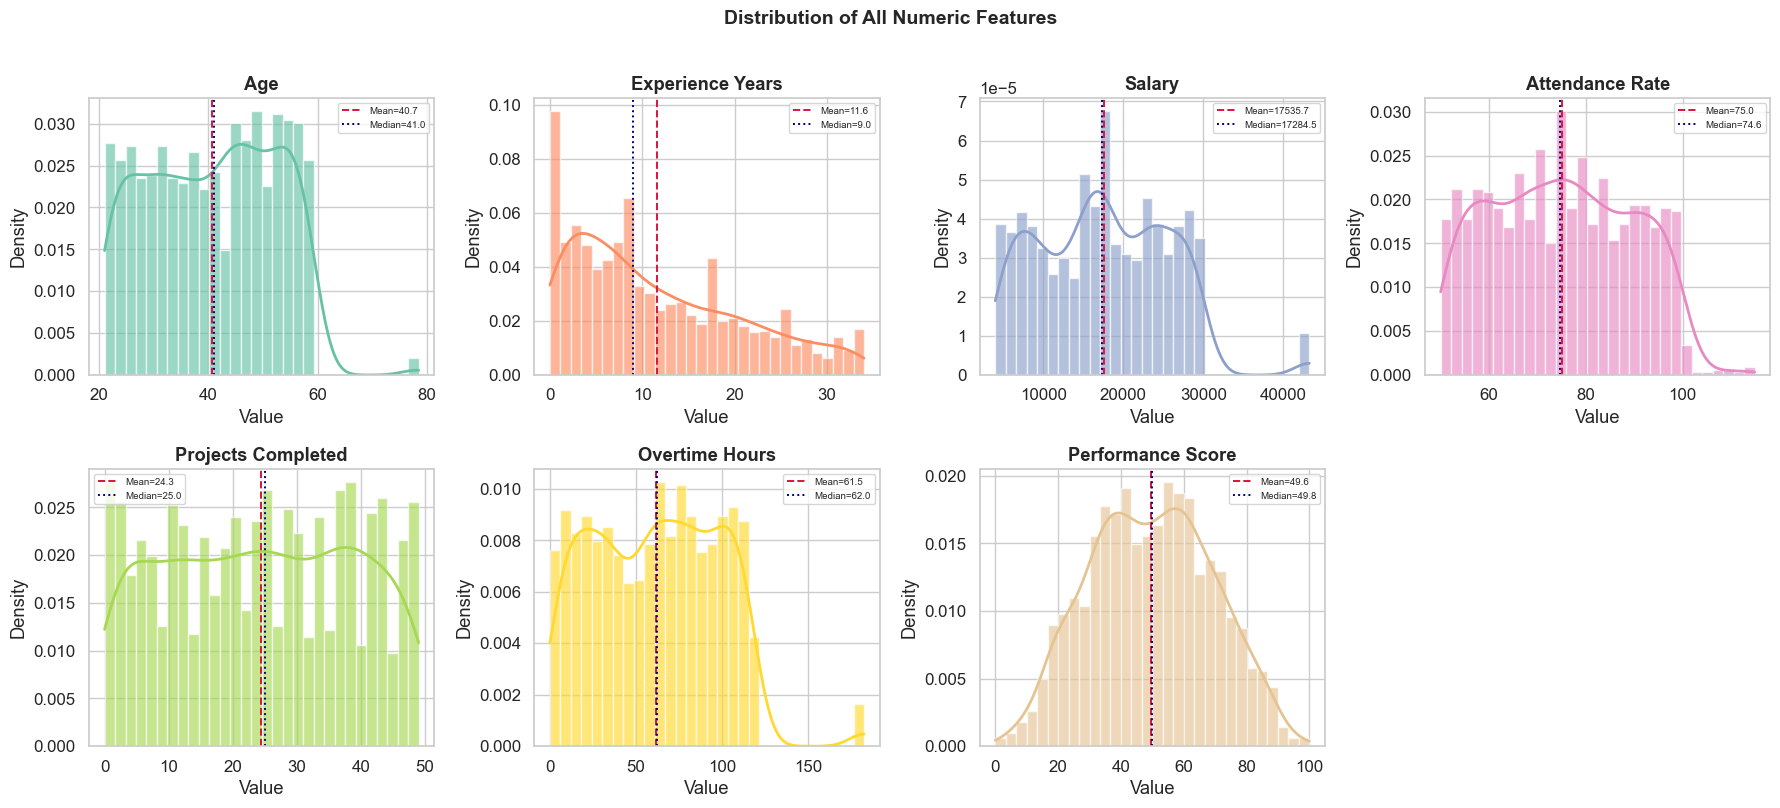

In [140]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
colors = sns.color_palette(PALETTE, len(NUMERIC_COLS))

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    ax.hist(df_clean_eda[col], bins=30, color=colors[i], alpha=0.65,
            edgecolor="white", density=True)
    col_data = df_clean_eda[col]
    kde_x = np.linspace(col_data.min(), col_data.max(), 200)
    ax.plot(kde_x, stats.gaussian_kde(col_data)(kde_x), lw=2, color=colors[i])
    ax.axvline(df_clean_eda[col].mean(skipna=True),   color="crimson", lw=1.4, ls="--",
               label=f"Mean={df_clean_eda[col].mean(skipna=True):.1f}")
    ax.axvline(df_clean_eda[col].median(skipna=True), color="navy",    lw=1.4, ls=":",
               label=f"Median={df_clean_eda[col].median(skipna=True):.1f}")
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("Value"); ax.set_ylabel("Density")
    ax.legend(fontsize=7)

axes[-1].set_visible(False)
fig.suptitle("Distribution of All Numeric Features", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

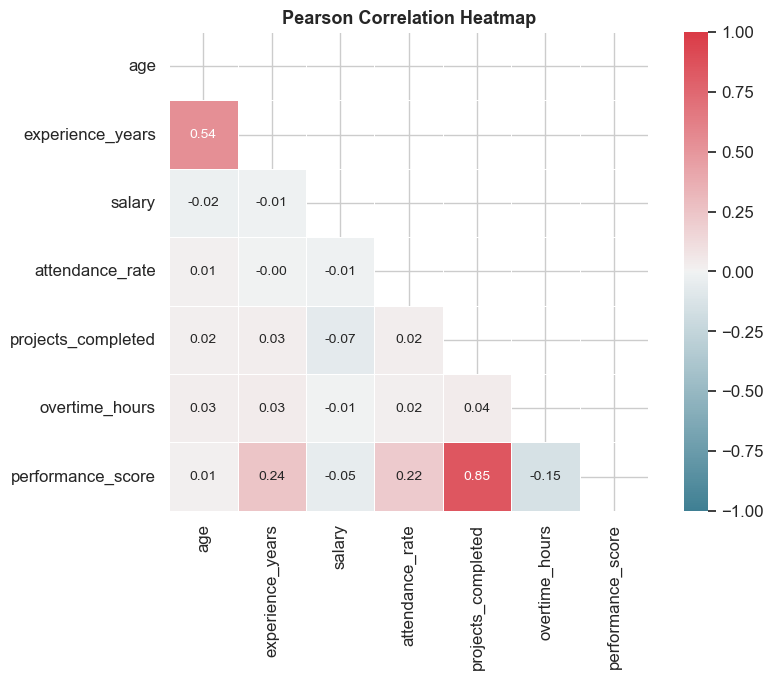

In [141]:
corr = df_clean_eda[NUMERIC_COLS].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt=".2f", linewidths=0.5, square=True,
            annot_kws={"size": 10}, ax=ax)
ax.set_title("Pearson Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

This plot shows how the numeric features in the dataset are related to each other.

The strongest relationship is between **projects completed and performance score**, meaning employees who complete more projects tend to have significantly higher performance.

Experience years and attendance rate have a weak to moderate positive relationship with performance, so they contribute but are not the main drivers.

Overtime hours shows a slight negative relationship with performance, suggesting that working more overtime does not necessarily improve performance and may even reflect inefficiency or workload issues.

Salary has almost no meaningful correlation with any other feature, so it does not add much information for prediction or clustering.

Age and experience years are moderately correlated, which makes sense since older employees usually have more experience, but the relationship is not strong enough to cause redundancy concerns.

Overall, the analysis suggests that **projects completed is the most important feature**, while salary is the least informative and can likely be excluded during feature selection.


### Plot 3 — Categorical Feature Breakdown (Post-Cleaning)

**What it shows:** Employee distribution across departments and education levels after standardisation — confirming exactly 5 and 4 valid categories with balanced counts.

**Compare to Diagnostic 2:** The 20 broken department bars and 15 education variants have collapsed into clean, balanced groups.

**Key findings:**
- **Departments:** HR 343, Operations 304, Finance 302, IT 286, Marketing 271 — well-balanced 
- **Education:** PhD 416, High School 375, Master 373, Bachelor 342 — balanced across all tiers


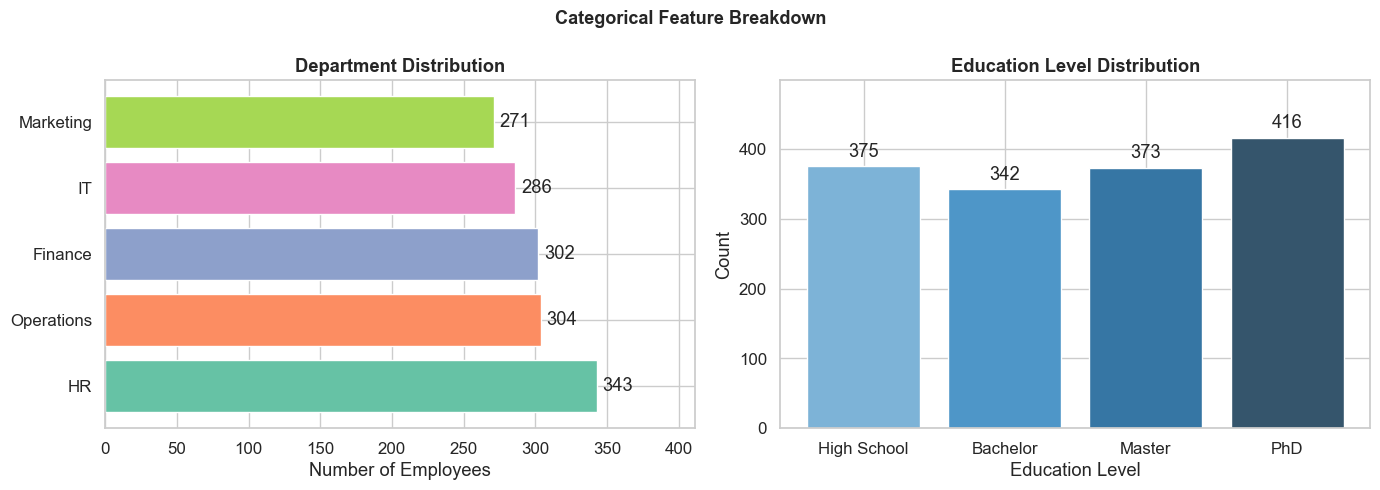

In [142]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dept_counts = df_clean_eda["department"].value_counts()
edu_order   = ["High School", "Bachelor", "Master", "PhD"]
edu_counts  = df_clean_eda["education_level"].value_counts().reindex(edu_order)

bars1 = axes[0].barh(dept_counts.index, dept_counts.values,
                     color=sns.color_palette(PALETTE, len(dept_counts)))
axes[0].set_xlabel("Number of Employees")
axes[0].set_title("Department Distribution", fontweight="bold")
axes[0].bar_label(bars1, padding=4)
axes[0].set_xlim(0, dept_counts.max() * 1.2)

bars2 = axes[1].bar(edu_counts.index, edu_counts.values,
                    color=sns.color_palette("Blues_d", len(edu_counts)))
axes[1].set_xlabel("Education Level"); axes[1].set_ylabel("Count")
axes[1].set_title("Education Level Distribution", fontweight="bold")
axes[1].bar_label(bars2, padding=4)
axes[1].set_ylim(0, edu_counts.max() * 1.2)

fig.suptitle("Categorical Feature Breakdown", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

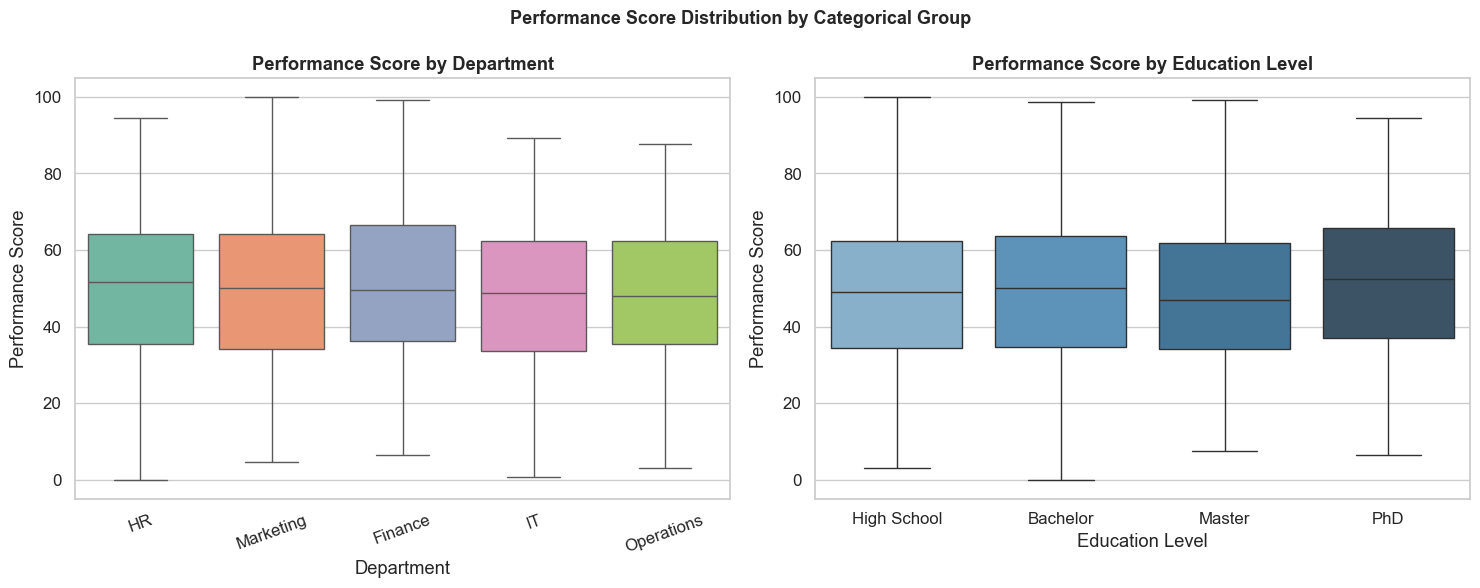

In [143]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

dept_order = (df_clean_eda.groupby("department")["performance_score"]
               .median().sort_values(ascending=False).index)
sns.boxplot(data=df_clean_eda, x="department", y="performance_score",
            order=dept_order, palette=PALETTE, ax=axes[0])
axes[0].set_title("Performance Score by Department", fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_xlabel("Department"); axes[0].set_ylabel("Performance Score")

edu_order_box = ["High School", "Bachelor", "Master", "PhD"]
sns.boxplot(data=df_clean_eda, x="education_level", y="performance_score",
            order=edu_order_box, palette="Blues_d", ax=axes[1])
axes[1].set_title("Performance Score by Education Level", fontweight="bold")
axes[1].set_xlabel("Education Level"); axes[1].set_ylabel("Performance Score")

fig.suptitle("Performance Score Distribution by Categorical Group",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Plot 4 — Performance Score by Department & Education

**What it shows:** Boxplots of `performance_score` stratified by department and education level — revealing whether either categorical variable drives performance outcomes.

**Key findings — by Department:**
- All departments cluster around median ≈ 50 with similar IQR 
- Finance and HR  sit marginally higher; Operations  and IT slightly lower
- No department outperforms )

**Key findings — by Education Level:**
- PhD:  highest performing group
- High School: lowest
- Bachelor and Master sit in between 


In [144]:
display(df_clean_eda.groupby("department")["performance_score"]
          .agg(["mean","median","std"]).round(2))
display(df_clean_eda.groupby("education_level")["performance_score"]
          .agg(["mean","median","std"]).round(2))

,mean,median,std
department,,,
Finance,50.67,49.50,19.72
HR,50.62,51.77,20.19
IT,48.61,48.66,18.61
Marketing,49.58,50.09,19.87
Operations,48.39,47.94,18.53


,mean,median,std
education_level,,,
Bachelor,49.72,50.15,19.74
High School,48.21,48.99,19.57
Master,48.50,46.94,19.07
PhD,51.79,52.45,19.17


---
### Feature Transformation



### Step 5 — Categorical Encoding

In [145]:
# department → One-Hot Encoding
dept_dummies = pd.get_dummies(df_proc["department"], prefix="dept", drop_first=False).astype(int)
df_proc = pd.concat([df_proc.drop(columns=["department"]), dept_dummies], axis=1)

# education_level → Ordinal Encoding
edu_map = {"High School": 0, "Bachelor": 1, "Master": 2, "PhD": 3}
df_proc["education_level_enc"] = df_proc["education_level"].map(edu_map)
df_proc = df_proc.drop(columns=["education_level"])

print("Encoding complete.")
print("One-hot columns:", list(dept_dummies.columns))
print("Ordinal mapping:", edu_map)
df_proc.head(3)

Encoding complete.
One-hot columns: ['dept_Finance', 'dept_HR', 'dept_IT', 'dept_Marketing', 'dept_Operations']
Ordinal mapping: {'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}


,age,experience_years,salary,attendance_rate,projects_completed,overtime_hours,performance_score,dept_Finance,dept_HR,dept_IT,dept_Marketing,dept_Operations,education_level_enc
0,59.0,15,22193.0,75.28,28,103.0,47.297374,0,1,0,0,0,3
1,49.0,26,7167.0,57.20,41,117.0,64.760494,0,0,1,0,0,0
2,35.0,7,15989.0,81.20,11,32.0,30.870878,0,0,0,0,1,1


**Justification:**

| Feature | Encoding | Reason |
|---|---|---|
| `department` | One-Hot (5 columns, `drop_first=False`) | Nominal — no natural ordering between HR, IT, Finance, etc. All dummies retained so the GA chromosome can evaluate each department's contribution independently |
| `education_level` | Ordinal `{High School:0, Bachelor:1, Master:2, PhD:3}` | Clear natural hierarchy exists. Ordinal encoding preserves this gradient, which is also meaningful as a Fuzzy Logic input variable |


### one hot encoding for  not ordinal features 

### Step 6 — Feature Scaling (StandardScaler)

In [146]:
# Scale all numeric features + ordinal education
# One-hot department columns are NOT scaled — binary 0/1 already on a
# comparable range; scaling them would create negative values and distort
# their meaning in Euclidean distance computations.
COLS_TO_SCALE = NUMERIC_COLS + ["education_level_enc"]

print("Pre-scaling statistics:")
display(df_proc[COLS_TO_SCALE].describe().T[["mean","std","min","max"]].round(3))

scaler = StandardScaler()
df_proc[COLS_TO_SCALE] = scaler.fit_transform(df_proc[COLS_TO_SCALE])

print("\nPost-scaling statistics (mean≈0, std≈1):")
display(df_proc[COLS_TO_SCALE].describe().T[["mean","std","min","max"]].round(3))

Pre-scaling statistics:


,mean,std,min,max
age,40.652,11.609,21.0,78.500
experience_years,11.566,9.156,0.0,34.000
salary,17535.682,8019.008,4025.0,43226.375
attendance_rate,74.994,14.403,50.0,114.891
projects_completed,24.333,14.493,0.0,49.000
overtime_hours,61.535,36.439,0.0,182.500
performance_score,49.613,19.413,0.0,100.000
education_level_enc,1.551,1.140,0.0,3.000



Post-scaling statistics (mean≈0, std≈1):


,mean,std,min,max
age,-0.0,1.0,-1.693,3.261
experience_years,-0.0,1.0,-1.264,2.451
salary,-0.0,1.0,-1.685,3.205
attendance_rate,-0.0,1.0,-1.736,2.771
projects_completed,0.0,1.0,-1.680,1.703
overtime_hours,0.0,1.0,-1.689,3.321
performance_score,0.0,1.0,-2.557,2.596
education_level_enc,0.0,1.0,-1.362,1.272


**Justification — StandardScaler (Z-score normalization):**

- **Why scale?** Feature magnitudes vary , Without scaling , `salary` would dominate every pairwise Euclidean distance computation in K-Medoid and Hierarchical clustering, effectively making all other features irrelevant.
- 
- **StandardScaler over MinMaxScaler** `salary`, `overtime_hours`, and `experience_years` are right-skewed . Z-score normalisation is more robust to residual skew than Min-Max, which compresses all variance into [0,1] and is highly sensitive to the boundary values we just winsorized.
- 
- **Why not scale one-hot columns?** Binary {0,1} indicators scaled to Z-scores produce fractional negative values, distorting their semantic meaning and inflating their Euclidean distance contribution. Left as-is, their 0/1 range is comparable to the range of Z-scored continuous features without rescaling.


---
### Feature Matrix Construction


### Step 7 — Feature Matrix Construction

In [147]:
# Full feature matrix for clustering (all columns after encoding + scaling)
# performance_score is RETAINED as a clustering feature — it is a measured
# KPI, not a derived label. Clustering on it helps identify natural
# performance-tier groupings in the workforce.
ALL_FEATURE_COLS = COLS_TO_SCALE + list(dept_dummies.columns)

X = df_proc[ALL_FEATURE_COLS].values

print(f"Feature matrix X shape: {X.shape}")
print(f"Features ({len(ALL_FEATURE_COLS)}):")
for i, c in enumerate(ALL_FEATURE_COLS, 1):
    print(f"  {i:>2}. {c}")

Feature matrix X shape: (1506, 13)
Features (13):
   1. age
   2. experience_years
   3. salary
   4. attendance_rate
   5. projects_completed
   6. overtime_hours
   7. performance_score
   8. education_level_enc
   9. dept_Finance
  10. dept_HR
  11. dept_IT
  12. dept_Marketing
  13. dept_Operations


### Final Preprocessed Dataset

In [148]:
print(f"Shape: {df_proc.shape}")
df_proc.head()

Shape: (1506, 13)


,age,experience_years,salary,attendance_rate,projects_completed,overtime_hours,performance_score,dept_Finance,dept_HR,dept_IT,dept_Marketing,dept_Operations,education_level_enc
0,1.581051,0.375144,0.580978,0.019879,0.253081,1.138314,-0.119346,0,1,0,0,0,1.271796
1,0.719346,1.576969,-1.293442,-1.235789,1.150370,1.522646,0.780512,0,0,1,0,0,-1.361556
2,-0.487041,-0.498910,-0.192941,0.431027,-0.920296,-0.810800,-0.965788,0,0,0,0,1,-0.483772
3,-1.090234,-0.608167,1.147695,-0.785749,-0.782252,0.259840,-0.586004,0,1,0,0,0,-0.483772
4,0.029982,0.484401,1.479143,-0.041932,1.564503,0.699077,1.120820,0,0,0,1,0,-0.483772


In [149]:
print(df_proc.columns.tolist())
print(df_proc.shape)

['age', 'experience_years', 'salary', 'attendance_rate', 'projects_completed', 'overtime_hours', 'performance_score', 'dept_Finance', 'dept_HR', 'dept_IT', 'dept_Marketing', 'dept_Operations', 'education_level_enc']
(1506, 13)


In [150]:
drop_cols = ['dept_Finance', 'dept_HR', 'dept_IT', 'dept_Marketing', 'dept_Operations']
feature_cols = [col for col in df_proc.columns if col not in drop_cols]
X = df_proc[feature_cols].values

print(f"Features: {feature_cols}")
print(f"Shape: {X.shape}")

Features: ['age', 'experience_years', 'salary', 'attendance_rate', 'projects_completed', 'overtime_hours', 'performance_score', 'education_level_enc']
Shape: (1506, 8)


### I dropped one hot encoded columns because it makes clustering with no meaning 

In [151]:
import numpy as np
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
import random
import warnings
warnings.filterwarnings('ignore')

# Baseline
baseline_kmed = KMedoids(n_clusters=3, random_state=42, max_iter=300)
baseline_labels = baseline_kmed.fit_predict(X)
baseline_score = silhouette_score(X, baseline_labels)
print(f"Baseline Silhouette (all features): {baseline_score:.4f}")

# GA Parameters
POP_SIZE = 30
N_FEATURES = X.shape[1]
N_GENERATIONS = 30
MUTATION_RATE = 0.2
K = 3

def fitness(chromosome):
    if chromosome.sum() < 3:
        return -1
    X_subset = X[:, chromosome == 1]
    try:
        kmed = KMedoids(n_clusters=K, random_state=42, max_iter=300)
        labels = kmed.fit_predict(X_subset)
        return silhouette_score(X_subset, labels)
    except:
        return -1

def init_population():
    pop = []
    for _ in range(POP_SIZE):
        chrom = np.random.randint(0, 2, N_FEATURES)
        if chrom.sum() < 3:
            zeros = np.where(chrom == 0)[0]
            chosen = random.sample(list(zeros), 3 - int(chrom.sum()))
            chrom[chosen] = 1
        pop.append(chrom)
    return pop

def crossover(p1, p2):
    point = random.randint(1, N_FEATURES - 1)
    c1 = np.concatenate([p1[:point], p2[point:]])
    c2 = np.concatenate([p2[:point], p1[point:]])
    return c1, c2

def mutate(chromosome):
    for i in range(N_FEATURES):
        if random.random() < MUTATION_RATE:
            chromosome[i] = 1 - chromosome[i]
    if chromosome.sum() < 3:
        zeros = np.where(chromosome == 0)[0]
        chosen = random.sample(list(zeros), 3 - int(chromosome.sum()))
        chromosome[chosen] = 1
    return chromosome

def select(pop, fitnesses):
    idx = random.sample(range(len(pop)), 3)
    best = max(idx, key=lambda i: fitnesses[i])
    return pop[best]

# Run GA
population = init_population()
best_score = -1
best_chromosome = None
history = []

print("Running GA...")
for gen in range(N_GENERATIONS):
    fitnesses = [fitness(c) for c in population]
    gen_best = max(fitnesses)
    history.append(gen_best)

    if gen_best > best_score:
        best_score = gen_best
        best_chromosome = population[np.argmax(fitnesses)].copy()

    new_pop = []
    while len(new_pop) < POP_SIZE:
        p1 = select(population, fitnesses)
        p2 = select(population, fitnesses)
        c1, c2 = crossover(p1, p2)
        new_pop.append(mutate(c1))
        new_pop.append(mutate(c2))
    population = new_pop[:POP_SIZE]
    print(f"Gen {gen+1}/{N_GENERATIONS} | Best Silhouette: {gen_best:.4f}")

selected_features = [feature_cols[i] for i in range(N_FEATURES) if best_chromosome[i] == 1]
print(f"\nBaseline Score: {baseline_score:.4f}")
print(f"GA Best Score:  {best_score:.4f}")
print(f"Selected Features: {selected_features}")

Baseline Silhouette (all features): 0.1066
Running GA...
Gen 1/30 | Best Silhouette: 0.3588
Gen 2/30 | Best Silhouette: 0.3588
Gen 3/30 | Best Silhouette: 0.3588
Gen 4/30 | Best Silhouette: 0.2710
Gen 5/30 | Best Silhouette: 0.2826
Gen 6/30 | Best Silhouette: 0.3575
Gen 7/30 | Best Silhouette: 0.3588
Gen 8/30 | Best Silhouette: 0.3588
Gen 9/30 | Best Silhouette: 0.3451
Gen 10/30 | Best Silhouette: 0.3451
Gen 11/30 | Best Silhouette: 0.3588
Gen 12/30 | Best Silhouette: 0.3588
Gen 13/30 | Best Silhouette: 0.3588
Gen 14/30 | Best Silhouette: 0.3451
Gen 15/30 | Best Silhouette: 0.3575
Gen 16/30 | Best Silhouette: 0.3454
Gen 17/30 | Best Silhouette: 0.3588
Gen 18/30 | Best Silhouette: 0.3575
Gen 19/30 | Best Silhouette: 0.3588
Gen 20/30 | Best Silhouette: 0.3454
Gen 21/30 | Best Silhouette: 0.3454
Gen 22/30 | Best Silhouette: 0.3588
Gen 23/30 | Best Silhouette: 0.3588
Gen 24/30 | Best Silhouette: 0.3588
Gen 25/30 | Best Silhouette: 0.3588
Gen 26/30 | Best Silhouette: 0.3588
Gen 27/30 | Best

### First, a baseline K-Medoids model was applied using all features, and the Silhouette Score was calculated as a reference.

### Then, the GA was used where each chromosome represents a combination of selected and unselected features using binary values (1 = selected, 0 = removed). For every chromosome, clustering was performed using only the selected features, and the Silhouette Score was used as the fitness value.

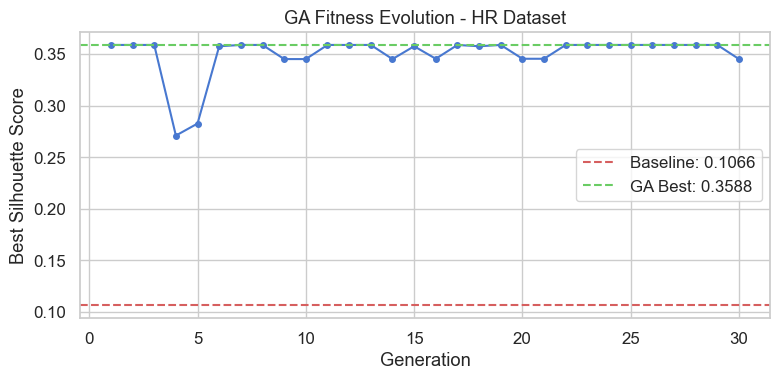

In [152]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, N_GENERATIONS + 1), history, 'b-o', markersize=4)
plt.axhline(y=baseline_score, color='r', linestyle='--', label=f'Baseline: {baseline_score:.4f}')
plt.axhline(y=best_score, color='g', linestyle='--', label=f'GA Best: {best_score:.4f}')
plt.xlabel('Generation')
plt.ylabel('Best Silhouette Score')
plt.title('GA Fitness Evolution - HR Dataset')
plt.legend()
plt.tight_layout()
plt.show()

#### This plot shows the progress of the Genetic Algorithm across generations.

#### The blue line represents the best Silhouette Score achieved in each generation. It illustrates how the GA gradually improves clustering performance while searching for the best feature subset.

#### The red dashed line shows the baseline score obtained using all features, while the green dashed line represents the best overall score found by the GA.

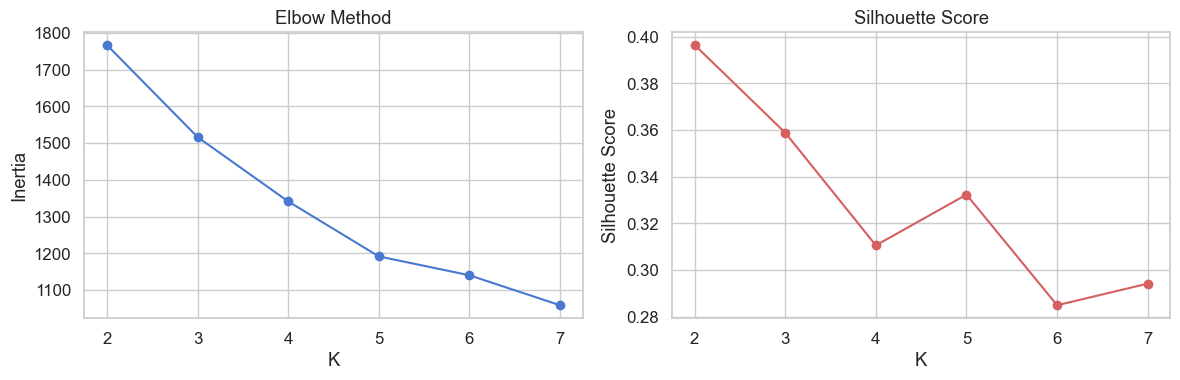

Silhouette Scores: {2: 0.3964, 3: 0.3588, 4: 0.3105, 5: 0.3323, 6: 0.2849, 7: 0.2941}


In [153]:
X_full = df_proc[selected_features].values

inertias = []
silhouettes = []
K_range = range(2, 8)

for k in K_range:
    kmed = KMedoids(n_clusters=k, random_state=42, max_iter=300)
    labels = kmed.fit_predict(X_full)
    inertias.append(kmed.inertia_)
    silhouettes.append(silhouette_score(X_full, labels))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes, 'ro-')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')

plt.tight_layout()
plt.show()

print("Silhouette Scores:", {k: round(s, 4) for k, s in zip(K_range, silhouettes)})

## Task 3: K-Medoid Clustering

### Determining Optimal Number of Clusters

### To identify the optimal number of clusters, we apply two complementary methods:

#### **Elbow Method:** We plot the inertia (sum of distances between each point and its medoid) for K values ranging from 2 to 7. The optimal K is where the curve starts to flatten — forming an "elbow" — indicating that adding more clusters yields diminishing returns.

#### **Silhouette Score:** Measures how similar each point is to its own cluster compared to other clusters. Values range from -1 to 1, where higher values indicate better-defined clusters. The optimal K corresponds to the highest silhouette score.



### Although k=2 has better score i perfer to choose k=3 
#### it's so close score and has better meaning according to bussiness view and help more in take decesions 

In [154]:
X_full = df_proc[selected_features].values

kmed_final = KMedoids(n_clusters=3, random_state=42, max_iter=300)
clusters = kmed_final.fit_predict(X_full)

df_proc['Cluster'] = clusters

cluster_summary = df_proc.groupby('Cluster')[['experience_years', 'projects_completed', 
                                               'performance_score', 'salary',
                                               'attendance_rate']].mean().round(3)
print(cluster_summary)
print("\nCluster Sizes:")
print(df_proc['Cluster'].value_counts().sort_index())

         experience_years  projects_completed  performance_score  salary  \
Cluster                                                                    
0                  -0.650               0.646              0.445   0.015   
1                   1.173               0.708              0.932  -0.158   
2                  -0.150              -1.000             -0.962   0.084   

         attendance_rate  
Cluster                   
0                  0.036  
1                  0.129  
2                 -0.110  

Cluster Sizes:
Cluster
0    530
1    371
2    605
Name: count, dtype: int64


In [155]:
print(scaler.feature_names_in_)

['age' 'experience_years' 'salary' 'attendance_rate' 'projects_completed'
 'overtime_hours' 'performance_score' 'education_level_enc']


In [156]:
scale_cols = ['age', 'experience_years', 'salary', 'attendance_rate', 
              'projects_completed', 'overtime_hours', 'performance_score', 
              'education_level_enc']

df_original_scale = df_proc.copy()
df_original_scale[scale_cols] = scaler.inverse_transform(df_proc[scale_cols])

cluster_summary = df_original_scale.groupby('Cluster')[['experience_years', 'projects_completed',
                                                          'performance_score', 'salary',
                                                          'attendance_rate']].mean().round(2)
print(cluster_summary)

         experience_years  projects_completed  performance_score    salary  \
Cluster                                                                      
0                    5.61               33.69              58.26  17656.60   
1                   22.30               34.58              67.70  16266.86   
2                   10.20                9.85              30.95  18207.82   

         attendance_rate  
Cluster                   
0                  75.51  
1                  76.85  
2                  73.41  


#### inverse transform to help me in understanding the clusters and give them labels :

#### cluster 0 : lower exp years but with high no. of projects completed and good performance score and attendance rate make these employee promising 
#### cluster 1 : highest exp years "seniors " with the best score and highest no of proj make them top performers 
#### cluster 2 : high exp years bad performance score and low number of projects and the lowest att. rate make them underperforming 

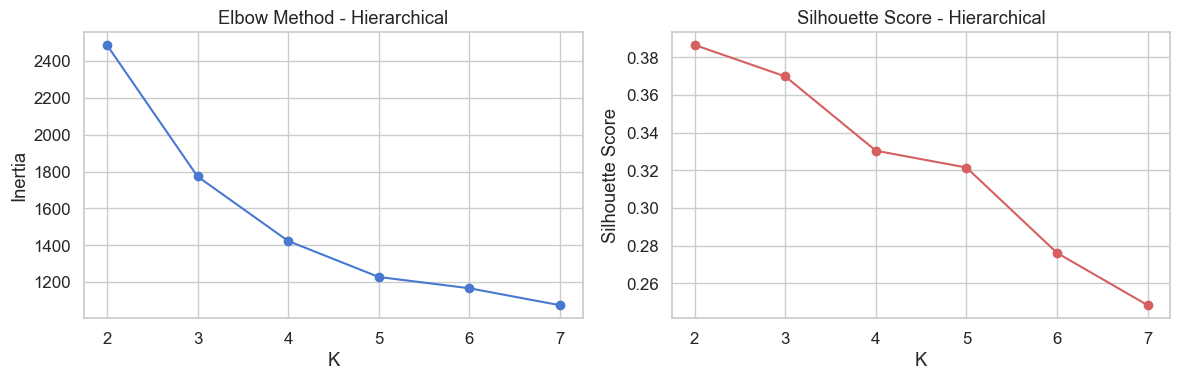

Silhouette Scores: {2: 0.3865, 3: 0.3698, 4: 0.3304, 5: 0.3214, 6: 0.2761, 7: 0.2484}


In [157]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score

inertias_hier = []
silhouettes_hier = []
K_range = range(2, 8)

for k in K_range:
    Z = linkage(X_full, method='average')
    labels = fcluster(Z, t=k, criterion='maxclust')
    
    # Inertia manually
    inertia = 0
    for cluster_id in np.unique(labels):
        cluster_points = X_full[labels == cluster_id]
        centroid = cluster_points.mean(axis=0)
        inertia += ((cluster_points - centroid) ** 2).sum()
    inertias_hier.append(inertia)
    silhouettes_hier.append(silhouette_score(X_full, labels))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias_hier, 'bo-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method - Hierarchical')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes_hier, 'ro-')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score - Hierarchical')

plt.tight_layout()
plt.show()

print("Silhouette Scores:", {k: round(s, 4) for k, s in zip(K_range, silhouettes_hier)})

#### using the avg linkage method, I apply the Elbow Method and Silhouette Score to determine the optimal number of clusters.
#### K=3 : Consistent with the K-Medoid results and better in meaning with close margin with k=2

In [158]:
from scipy.cluster.hierarchy import linkage, fcluster

for method in ['ward', 'complete', 'average']:
    Z = linkage(X_full, method=method)
    labels = fcluster(Z, t=3, criterion='maxclust')
    score = silhouette_score(X_full, labels)
    print(f"{method}: Silhouette = {score:.4f}")

ward: Silhouette = 0.3002
complete: Silhouette = 0.3477
average: Silhouette = 0.3698


In [159]:
#### best score is avg method so i complete the whole clustering with it 

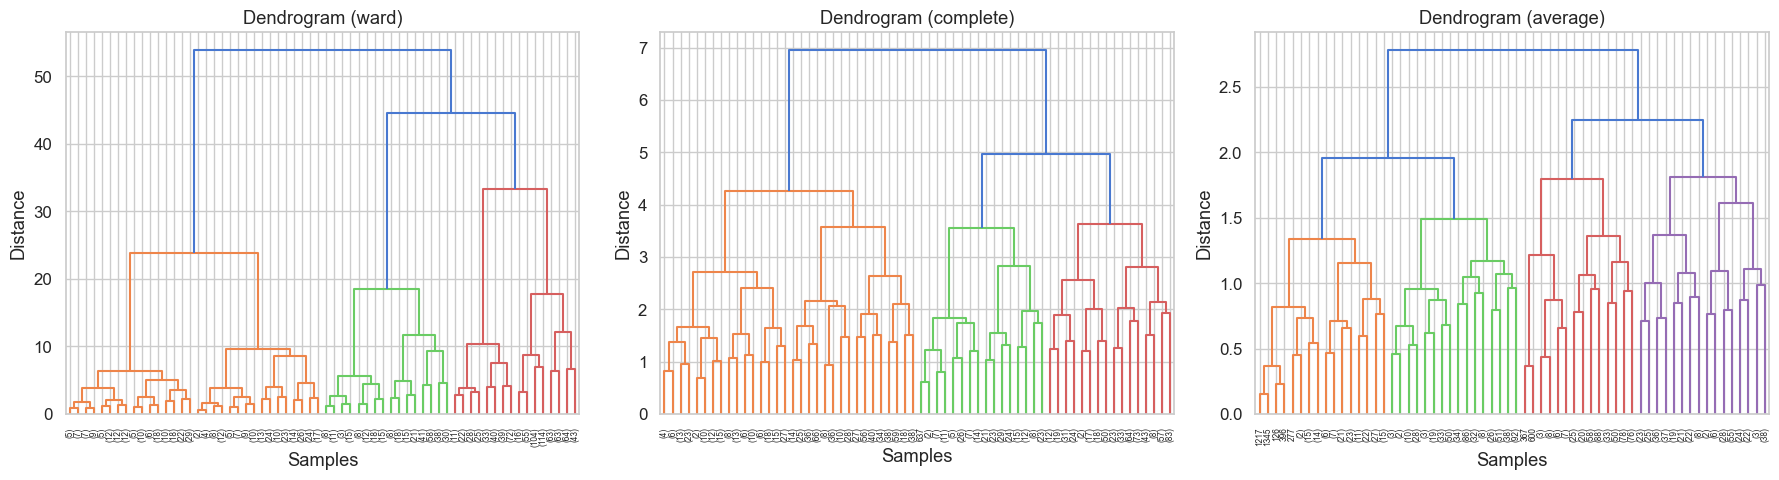

In [160]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, method in zip(axes, ['ward', 'complete', 'average']):
    Z = linkage(X_full, method=method)
    dendrogram(Z, ax=ax, truncate_mode='level', p=5, leaf_rotation=90)
    ax.set_title(f'Dendrogram ({method})')
    ax.set_xlabel('Samples')
    ax.set_ylabel('Distance')

plt.tight_layout()
plt.show()

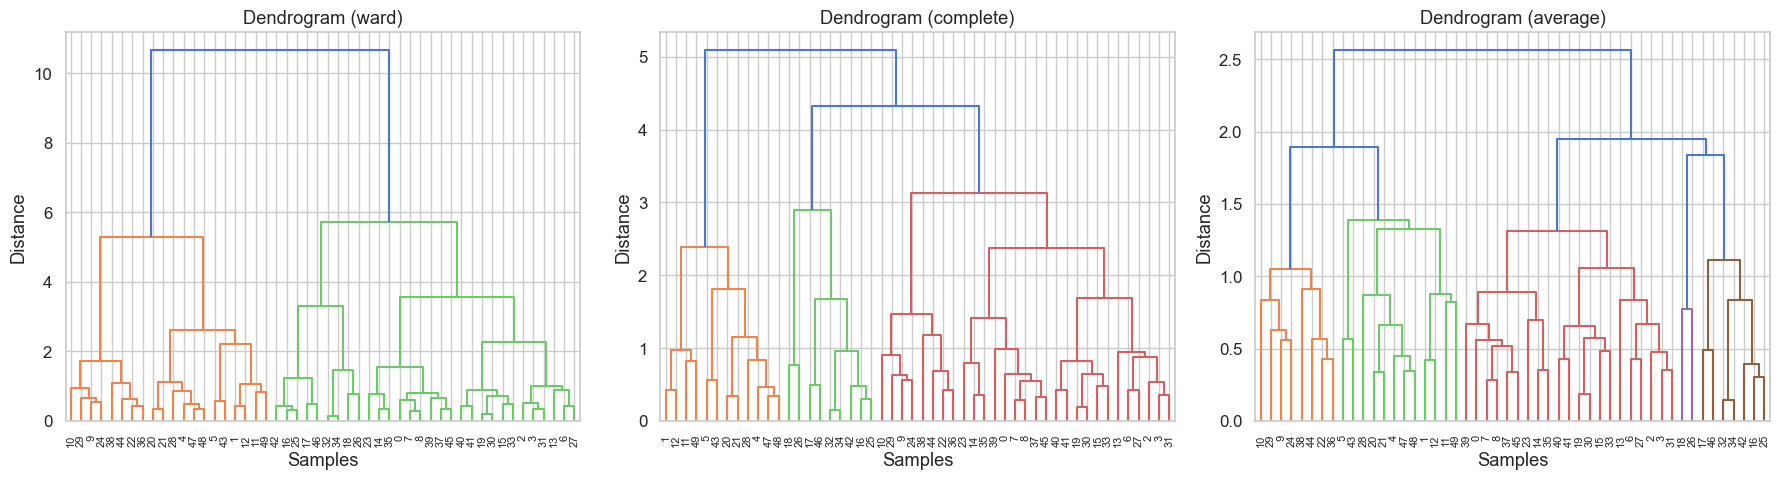

In [161]:
from scipy.cluster.hierarchy import dendrogram, linkage

X_sample_dend = X_full[:50]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, method in zip(axes, ['ward', 'complete', 'average']):
    Z = linkage(X_sample_dend, method=method)
    dendrogram(Z, ax=ax, leaf_rotation=90, leaf_font_size=8)
    ax.set_title(f'Dendrogram ({method})')
    ax.set_xlabel('Samples')
    ax.set_ylabel('Distance')

plt.tight_layout()
plt.show()

In [162]:
from scipy.cluster.hierarchy import linkage, fcluster

Z_best = linkage(X_full, method='average')
hier_labels = fcluster(Z_best, t=3, criterion='maxclust') - 1

df_proc['Hier_Cluster'] = hier_labels

print("Cluster Sizes:")
print(df_proc['Hier_Cluster'].value_counts().sort_index())

Cluster Sizes:
Hier_Cluster
0    683
1    454
2    369
Name: count, dtype: int64


In [163]:
df_original_scale['Hier_Cluster'] = hier_labels

hier_summary = df_original_scale.groupby('Hier_Cluster')[['experience_years', 'projects_completed',
                                                            'performance_score', 'salary',
                                                            'attendance_rate']].mean().round(2)
print(hier_summary)

              experience_years  projects_completed  performance_score  \
Hier_Cluster                                                            
0                         9.38               11.48              32.47   
1                         5.87               37.61              63.39   
2                        22.61               31.80              64.41   

                salary  attendance_rate  
Hier_Cluster                             
0             18128.38            73.41  
1             17278.73            75.85  
2             16754.76            76.87  


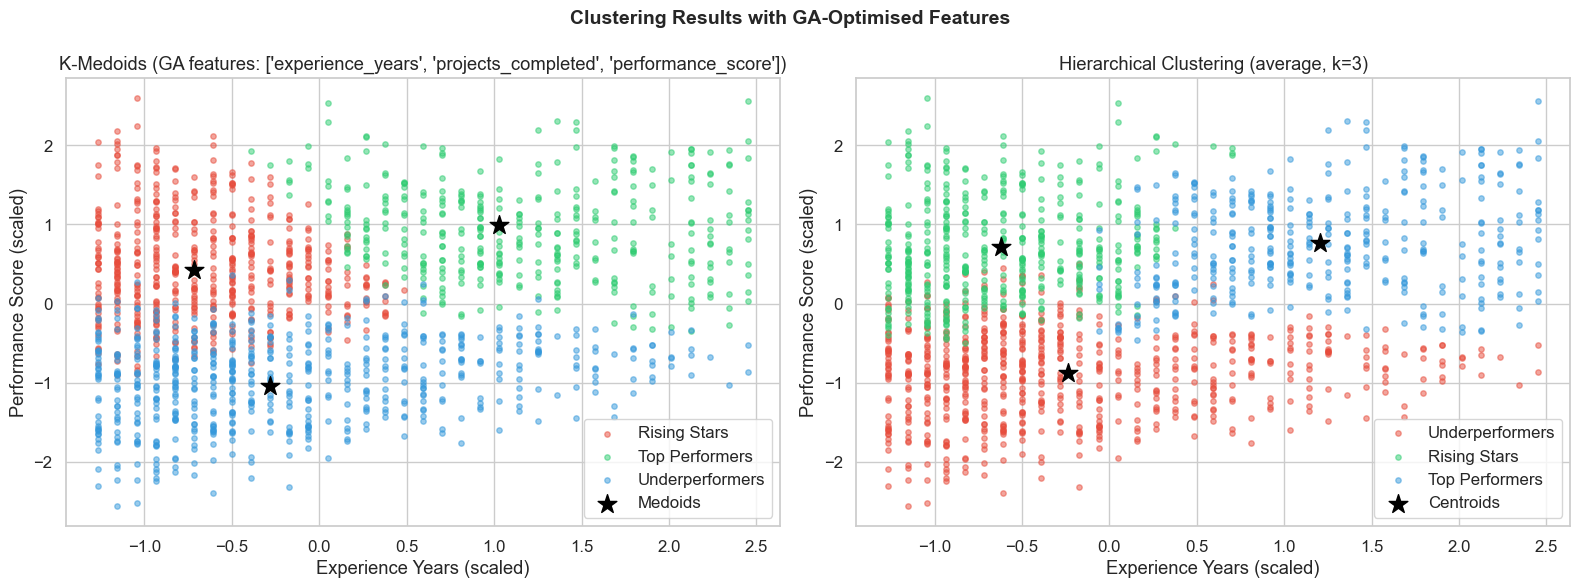

In [186]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: K-Medoid Clusters
colors_kmed = ['#e74c3c', '#2ecc71', '#3498db']
cluster_names_kmed = ['Rising Stars', 'Top Performers', 'Underperformers']

for i in range(3):
    mask = df_proc['Cluster'] == i
    axes[0].scatter(
        df_proc.loc[mask, 'experience_years'],
        df_proc.loc[mask, 'performance_score'],
        c=colors_kmed[i], label=cluster_names_kmed[i],
        alpha=0.5, s=15
    )

# Plot medoids
medoid_indices = kmed_final.medoid_indices_
axes[0].scatter(
    df_proc.iloc[medoid_indices]['experience_years'],
    df_proc.iloc[medoid_indices]['performance_score'],
    c='black', marker='*', s=200, label='Medoids', zorder=5
)
axes[0].set_xlabel('Experience Years (scaled)')
axes[0].set_ylabel('Performance Score (scaled)')
axes[0].set_title(f"K-Medoids (GA features: {selected_features})")
axes[0].legend()

# Plot 2: Hierarchical Clusters
colors_hier = ['#e74c3c', '#2ecc71', '#3498db']
cluster_names_hier = ['Underperformers', 'Rising Stars', 'Top Performers']

for i in range(3):
    mask = df_proc['Hier_Cluster'] == i
    axes[1].scatter(
        df_proc.loc[mask, 'experience_years'],
        df_proc.loc[mask, 'performance_score'],
        c=colors_hier[i], label=cluster_names_hier[i],
        alpha=0.5, s=15
    )

# Plot hier centers
axes[1].scatter(
    hier_centers[:, 0],
    hier_centers[:, 2],
    c='black', marker='*', s=200, label='Centroids', zorder=5
)
axes[1].set_xlabel('Experience Years (scaled)')
axes[1].set_ylabel('Performance Score (scaled)')
axes[1].set_title('Hierarchical Clustering (average, k=3)')
axes[1].legend()

plt.suptitle('Clustering Results with GA-Optimised Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Both methods agree that performance score is the primary differentiator between clusters, while experience years helps separate Rising Stars from Top Performers. The overlap between clusters is expected since the visualization uses only 2 of the 3 GA-selected features

In [164]:
#### cluster 0 : underperformed 
#### cluster 1 : rising stars 
#### cluster 2 : top performed

In [165]:
for col in ['performance_score', 'projects_completed']:
    Q1 = df_original_scale[col].quantile(0.25)
    Q3 = df_original_scale[col].quantile(0.75)
    median = df_original_scale[col].median()
    min_val = df_original_scale[col].min()
    max_val = df_original_scale[col].max()
    print(f"{col}: Min={min_val:.2f}, Q1={Q1:.2f}, Median={median:.2f}, Q3={Q3:.2f}, Max={max_val:.2f}")

performance_score: Min=0.00, Q1=34.88, Median=49.83, Q3=63.62, Max=100.00
projects_completed: Min=0.00, Q1=12.00, Median=25.00, Q3=37.00, Max=49.00


In [166]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# 1. Universe 

performance = ctrl.Antecedent(np.arange(0, 101, 1), 'performance')
projects = ctrl.Antecedent(np.arange(0, 50, 1), 'projects')
cluster = ctrl.Antecedent(np.arange(0, 2.1, 0.1), 'cluster')
promotion_score = ctrl.Consequent(np.arange(0, 101, 1), 'promotion_score')





In [167]:
# 2. Membership Functions

# Performance (Min=0, Q1=35, Median=50, Q3=64, Max=100)
performance['low']    = fuzz.trimf(performance.universe, [0, 0, 50])
performance['medium'] = fuzz.trimf(performance.universe, [25, 50, 75])
performance['high']   = fuzz.trimf(performance.universe, [50, 100, 100])


# Projects (Min=0, Q1=12, Median=25, Q3=37, Max=49)

projects['low']    = fuzz.trimf(projects.universe, [0, 0, 25])
projects['medium'] = fuzz.trimf(projects.universe, [12, 25, 37])
projects['high']   = fuzz.trimf(projects.universe, [25, 49, 49])

# Cluster
cluster['rising_star']    = fuzz.trimf(cluster.universe, [0, 0, 0.5])
cluster['top_performer']  = fuzz.trimf(cluster.universe, [0.5, 1, 1.5])
cluster['underperformer'] = fuzz.trimf(cluster.universe, [1.5, 2, 2])

# Promotion Score
promotion_score['very_low']  = fuzz.trimf(promotion_score.universe, [0,   0,  25])
promotion_score['low']       = fuzz.trimf(promotion_score.universe, [0,  25,  50])
promotion_score['medium']    = fuzz.trimf(promotion_score.universe, [25, 50,  75])
promotion_score['high']      = fuzz.trimf(promotion_score.universe, [50, 75, 100])
promotion_score['very_high'] = fuzz.trimf(promotion_score.universe, [75, 100, 100])



In [192]:
# Top Performers (+1 level)
rule1  = ctrl.Rule(cluster['top_performer'] & performance['high']   & projects['high'],   promotion_score['very_high'])
rule2  = ctrl.Rule(cluster['top_performer'] & performance['high']   & projects['medium'], promotion_score['very_high'])
rule3  = ctrl.Rule(cluster['top_performer'] & performance['high']   & projects['low'],    promotion_score['high'])
rule4  = ctrl.Rule(cluster['top_performer'] & performance['medium'] & projects['high'],   promotion_score['very_high'])
rule5  = ctrl.Rule(cluster['top_performer'] & performance['medium'] & projects['medium'], promotion_score['high'])
rule6  = ctrl.Rule(cluster['top_performer'] & performance['medium'] & projects['low'],    promotion_score['medium'])
rule7  = ctrl.Rule(cluster['top_performer'] & performance['low']    & projects['high'],   promotion_score['high'])
rule8  = ctrl.Rule(cluster['top_performer'] & performance['low']    & projects['medium'], promotion_score['medium'])
rule9  = ctrl.Rule(cluster['top_performer'] & performance['low']    & projects['low'],    promotion_score['low'])

# Rising Stars (base level)
rule10 = ctrl.Rule(cluster['rising_star'] & performance['high']   & projects['high'],   promotion_score['very_high'])
rule11 = ctrl.Rule(cluster['rising_star'] & performance['high']   & projects['medium'], promotion_score['high'])
rule12 = ctrl.Rule(cluster['rising_star'] & performance['high']   & projects['low'],    promotion_score['medium'])
rule13 = ctrl.Rule(cluster['rising_star'] & performance['medium'] & projects['high'],   promotion_score['high'])
rule14 = ctrl.Rule(cluster['rising_star'] & performance['medium'] & projects['medium'], promotion_score['medium'])
rule15 = ctrl.Rule(cluster['rising_star'] & performance['medium'] & projects['low'],    promotion_score['low'])
rule16 = ctrl.Rule(cluster['rising_star'] & performance['low']    & projects['high'],   promotion_score['medium'])
rule17 = ctrl.Rule(cluster['rising_star'] & performance['low']    & projects['medium'], promotion_score['low'])
rule18 = ctrl.Rule(cluster['rising_star'] & performance['low']    & projects['low'],    promotion_score['very_low'])

# Underperformers (-1 level)
rule19 = ctrl.Rule(cluster['underperformer'] & performance['high']   & projects['high'],   promotion_score['high'])
rule20 = ctrl.Rule(cluster['underperformer'] & performance['high']   & projects['medium'], promotion_score['medium'])
rule21 = ctrl.Rule(cluster['underperformer'] & performance['high']   & projects['low'],    promotion_score['low'])
rule22 = ctrl.Rule(cluster['underperformer'] & performance['medium'] & projects['high'],   promotion_score['medium'])
rule23 = ctrl.Rule(cluster['underperformer'] & performance['medium'] & projects['medium'], promotion_score['low'])
rule24 = ctrl.Rule(cluster['underperformer'] & performance['medium'] & projects['low'],    promotion_score['very_low'])
rule25 = ctrl.Rule(cluster['underperformer'] & performance['low']    & projects['high'],   promotion_score['low'])
rule26 = ctrl.Rule(cluster['underperformer'] & performance['low']    & projects['medium'], promotion_score['very_low'])
rule27 = ctrl.Rule(cluster['underperformer'] & performance['low']    & projects['low'],    promotion_score['very_low'])

### Rule Design Methodology

#### The 27 rules are structured using a **Cluster-Based Priority Weighting** approach. A base rule table is first defined for the Rising Star cluster, where the promotion score is determined solely by the combination of performance level and projects completed. Top Performers receive a +1 level boost to their score reflecting their strong historical track record, while Underperformers receive a -1 level penalty reflecting their history of low productivity. This ensures that the cluster assignment directly influences the promotion decision in a fair and systematic way.

In [ ]:
### 

Fuzzy System built successfully!


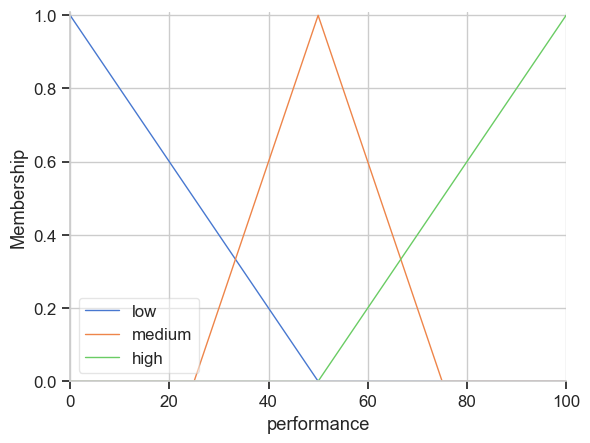

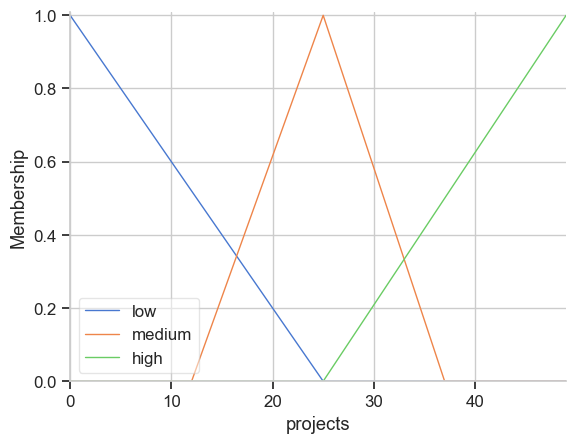

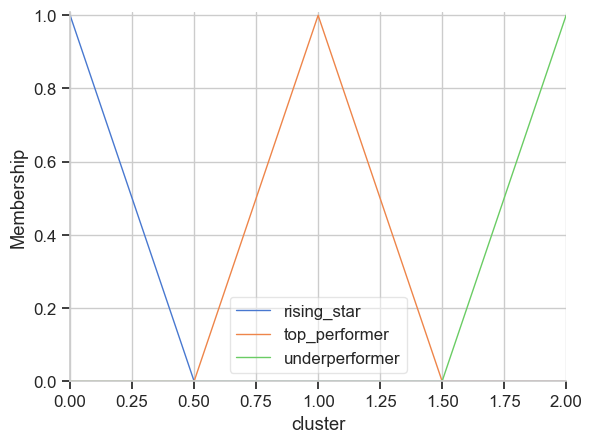

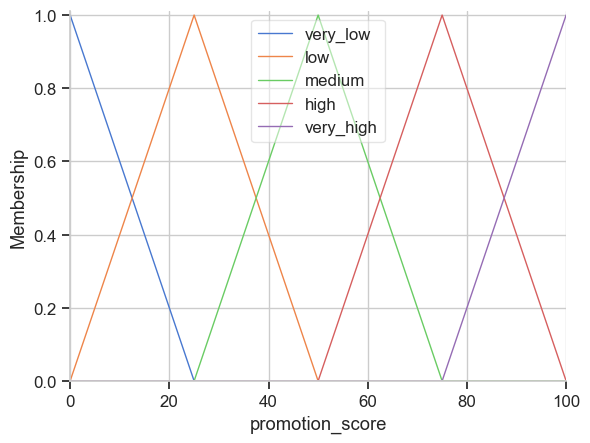

In [188]:
#  Control System
promotion_ctrl = ctrl.ControlSystem([
    rule1,  rule2,  rule3,  rule4,  rule5,  rule6,  rule7,  rule8,  rule9,
    rule10, rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18,
    rule19, rule20, rule21, rule22, rule23, rule24, rule25, rule26, rule27
])
promotion_sim = ctrl.ControlSystemSimulation(promotion_ctrl)
print("Fuzzy System built successfully!")

performance.view()
projects.view()
cluster.view()
promotion_score.view()

plt.show()

Top Performer - Promotion Score: 91.1


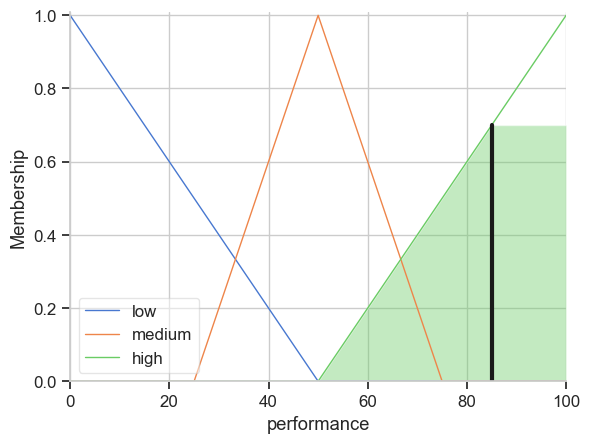

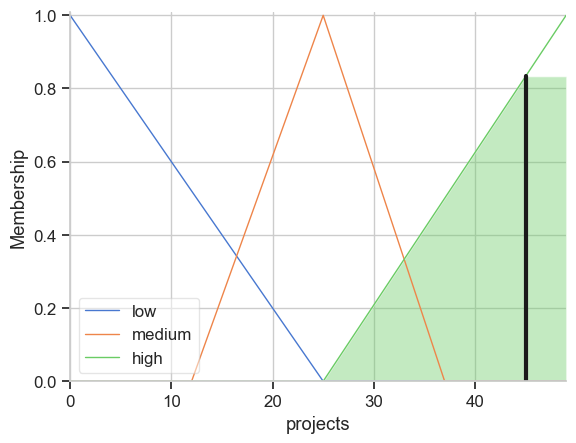

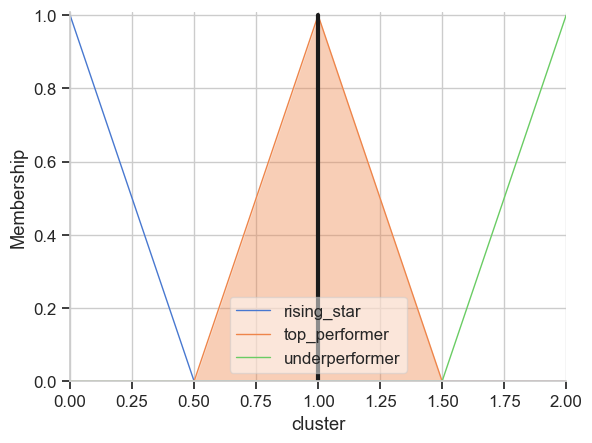

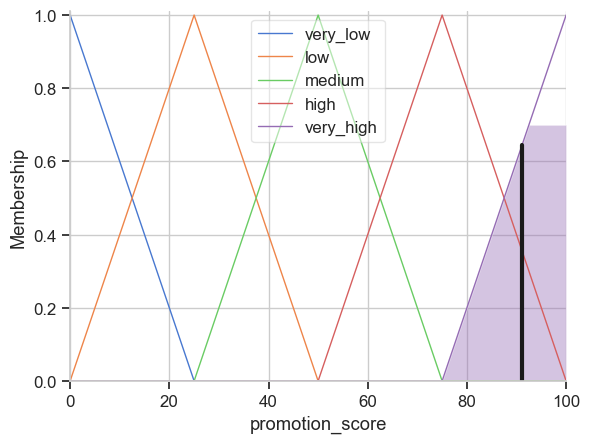

In [176]:
promotion_sim.input['performance'] = 85
promotion_sim.input['projects'] = 45
promotion_sim.input['cluster'] = 1
promotion_sim.compute()
print(f"Top Performer - Promotion Score: {round(promotion_sim.output['promotion_score'], 1)}")
performance.view(promotion_sim)
projects.view(promotion_sim)
cluster.view(promotion_sim)
promotion_score.view(promotion_sim)
plt.show()

Rising Star - Promotion Score: 51.1


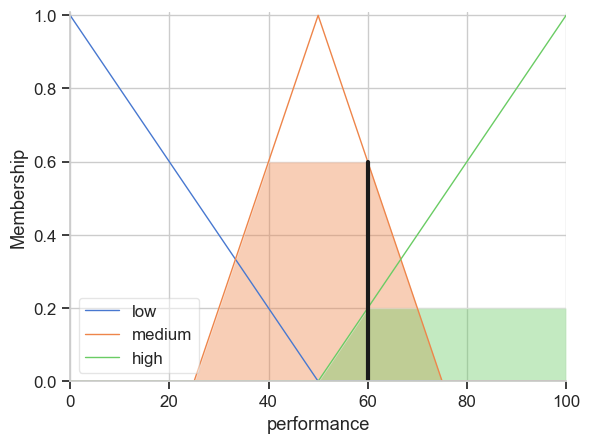

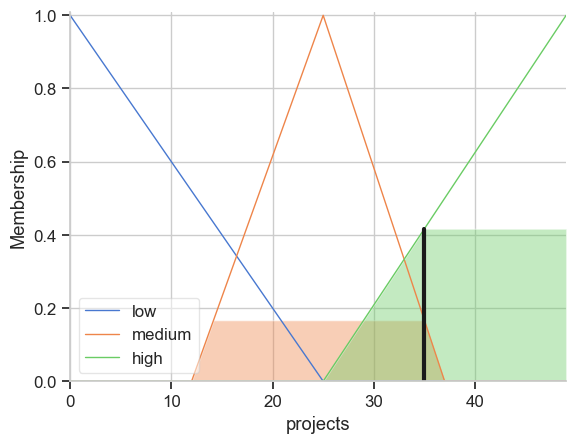

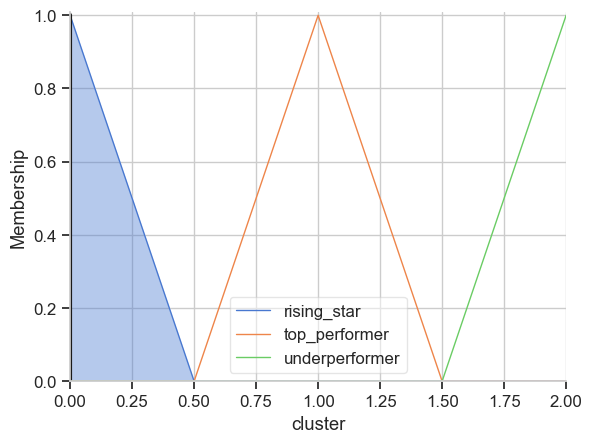

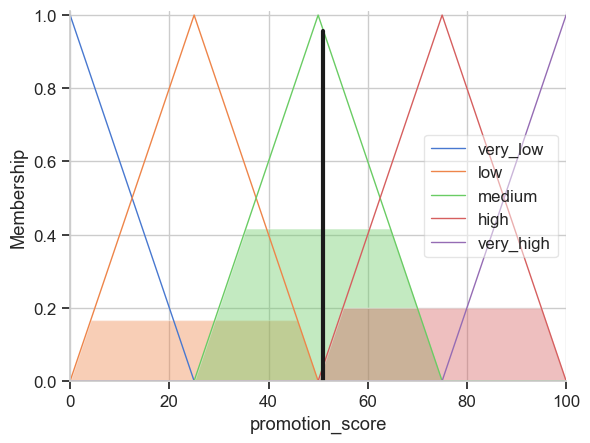

In [177]:
promotion_sim.input['performance'] = 60
promotion_sim.input['projects'] = 35
promotion_sim.input['cluster'] = 0
promotion_sim.compute()
print(f"Rising Star - Promotion Score: {round(promotion_sim.output['promotion_score'], 1)}")
performance.view(promotion_sim)
projects.view(promotion_sim)
cluster.view(promotion_sim)
promotion_score.view(promotion_sim)
plt.show()

Underperformer - Promotion Score: 9.7


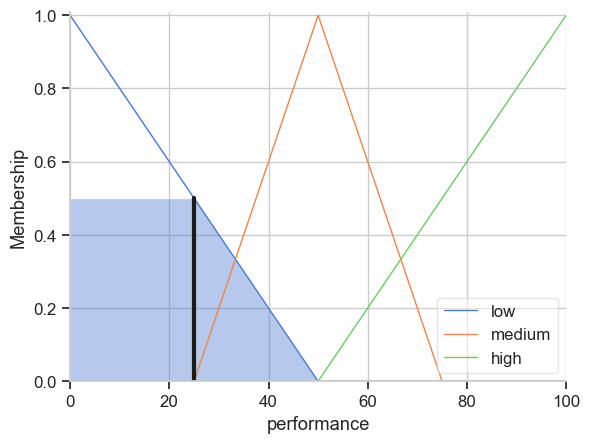

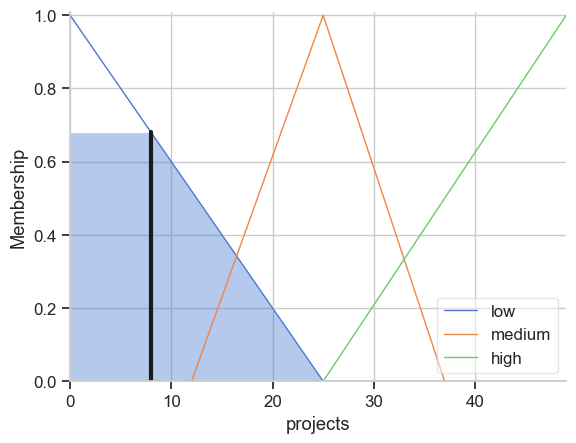

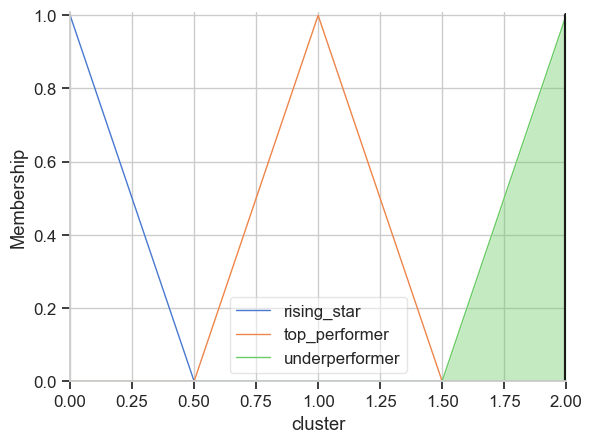

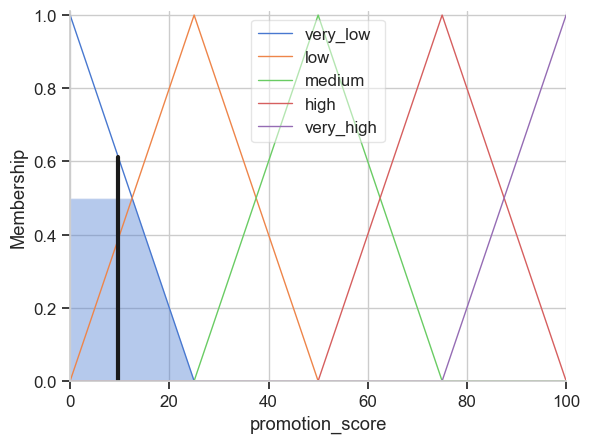

In [178]:
promotion_sim.input['performance'] = 25
promotion_sim.input['projects'] = 8
promotion_sim.input['cluster'] = 2
promotion_sim.compute()
print(f"Underperformer - Promotion Score: {round(promotion_sim.output['promotion_score'], 1)}")
performance.view(promotion_sim)
projects.view(promotion_sim)
cluster.view(promotion_sim)
promotion_score.view(promotion_sim)
plt.show()

In [172]:
samples = df_original_scale.groupby('Cluster').apply(lambda x: x.sample(3, random_state=84)).reset_index(drop=True)

results = []
for _, row in samples.iterrows():
    try:
        promotion_sim.input['performance'] = row['performance_score']
        promotion_sim.input['projects'] = row['projects_completed']
        promotion_sim.input['cluster'] = row['Cluster']
        
        promotion_sim.compute()
        score = round(promotion_sim.output['promotion_score'], 2)
    except:
        score = None
    
    results.append({
        'Cluster': int(row['Cluster']),
        'Performance': round(row['performance_score'], 2),
        'Projects': round(row['projects_completed'], 2),
        'Promotion_Score': score
    })

results_df = pd.DataFrame(results)
print(results_df.to_string())

   Cluster  Performance  Projects  Promotion_Score
0        0        50.53      33.0            38.09
1        0        54.25      33.0            41.77
2        0        45.97      35.0            42.69
3        1        86.54      48.0            91.19
4        1        58.42      30.0            57.59
5        1        92.13      47.0            91.49
6        2        20.09      11.0             9.45
7        2        25.86       4.0             9.80
8        2        40.40       6.0             9.22



#### To validate the fuzzy system, we test it on 3 real employees from each cluster (9 total) drawn directly from the dataset. The results confirm that the system produces meaningful and consistent promotion scores aligned with each employee's cluster profile and actual performance metrics.

In [191]:
hier_centers = df_proc.groupby('Hier_Cluster')[selected_features].mean().values

def employee_pipeline(employee_record, scaler, kmed_model, selected_features, 
                      promotion_sim, hier_centers, ga_best_score):
    """
    Comprehensive HR Analytics Pipeline
    
    Arguments:
    - employee_record  : dict of raw employee data
    - scaler           : fitted StandardScaler from preprocessing
    - kmed_model       : fitted KMedoids model
    - selected_features: list of features selected by Genetic Algorithm
    - promotion_sim    : fitted Fuzzy Logic control system simulation
    - hier_centers     : cluster centers from Hierarchical Clustering
    - ga_best_score    : best silhouette score achieved by GA
    """
    
    record = employee_record.copy()
    
    # Step 1: Scaling
    scale_cols = ['age', 'experience_years', 'salary', 'attendance_rate',
                  'projects_completed', 'overtime_hours', 'performance_score', 
                  'education_level_enc']
    record_df = pd.DataFrame([record])[scale_cols]
    record_scaled = scaler.transform(record_df)
    record_scaled_df = pd.DataFrame(record_scaled, columns=scale_cols)
    
    # Step 2: K-Medoid Clustering
    X_record = record_scaled_df[selected_features].values
    kmed_cluster = kmed_model.predict(X_record)[0]
    
    # Step 3: Hierarchical Clustering
    from scipy.spatial.distance import cdist
    distances = cdist(X_record, hier_centers)
    hier_cluster = np.argmin(distances)
    
    # Step 4: Fuzzy Logic
    promotion_sim.input['performance'] = record['performance_score']
    promotion_sim.input['projects']    = record['projects_completed']
    promotion_sim.input['cluster']     = float(kmed_cluster)
    promotion_sim.compute()
    score = round(promotion_sim.output['promotion_score'], 2)
    
    # Step 5: Insight
    if score >= 75:
        insight = "Strong promotion candidate. Recommend immediate promotion consideration."
    elif score >= 50:
        insight = "Potential promotion candidate. Recommend performance review and development plan."
    elif score >= 25:
        insight = "Not ready for promotion. Recommend targeted training and closer monitoring."
    else:
        insight = "Significant performance gap. Recommend performance improvement plan (PIP)."
    
    # Step 6: Output
    kmed_names = {0: 'Rising Stars', 1: 'Top Performers', 2: 'Underperformers'}
    hier_names = {0: 'Underperformers', 1: 'Rising Stars', 2: 'Top Performers'}
    
    print(f"{'='*45}")
    print(f"  Employee Pipeline Results")
    print(f"{'='*45}")
    print(f"  GA Best Silhouette Score: {ga_best_score:.4f}")
    print(f"  K-Medoid Cluster:         {kmed_cluster} ({kmed_names[kmed_cluster]})")
    print(f"  Hierarchical Cluster:     {hier_cluster} ({hier_names[hier_cluster]})")
    print(f"  Performance Score:        {record['performance_score']}")
    print(f"  Projects Completed:       {record['projects_completed']}")
    print(f"  Promotion Score:          {score}/100")
    print(f"  Insight:                  {insight}")
    print(f"{'='*45}")
    
    return {
        'kmed_cluster'      : kmed_cluster,
        'kmed_cluster_name' : kmed_names[kmed_cluster],
        'hier_cluster'      : hier_cluster,
        'hier_cluster_name' : hier_names[hier_cluster],
        'promotion_score'   : score,
        'insight'           : insight
    }

# Test
test_employee = {
    'age':  35,
    'experience_years': 10 ,
    'salary': 20000,
    'attendance_rate': 70,
    'projects_completed': 42,
    'overtime_hours': 5,
    'performance_score': 85,
    'education_level_enc': 1
}

result = employee_pipeline(
    employee_record   = test_employee,
    scaler            = scaler,
    kmed_model        = kmed_final,
    selected_features = selected_features,
    promotion_sim     = promotion_sim,
    hier_centers      = hier_centers,
    ga_best_score     = best_score
)

  Employee Pipeline Results
  GA Best Silhouette Score: 0.3588
  K-Medoid Cluster:         1 (Top Performers)
  Hierarchical Cluster:     1 (Rising Stars)
  Performance Score:        85
  Projects Completed:       42
  Promotion Score:          91.09/100
  Insight:                  Strong promotion candidate. Recommend immediate promotion consideration.


## Task 7: System Implementation

### Pipeline Overview

The employee_pipeline function serves as the backbone of this project, integrating all implemented algorithms into a single end-to-end decision support system. It accepts a raw employee record alongside all fitted models and returns a data-driven promotion recommendation.

### Pipeline Arguments
- employee_record   : Raw employee data as a dictionary
- scaler            : Fitted StandardScaler from preprocessing step
- kmed_model        : Fitted K-Medoid model trained on GA-selected features
- selected_features : Optimal feature subset identified by the Genetic Algorithm
- promotion_sim     : Fitted Fuzzy Logic control system
- hier_centers      : Pre-computed Hierarchical cluster centers
- ga_best_score     : Best Silhouette Score achieved by the GA (used as reference)

### Pipeline Flow
1. Raw employee data is scaled using the fitted StandardScaler
2. GA-selected features are extracted from the scaled record
3. K-Medoid model assigns the employee to a cluster
4. Hierarchical clustering confirms the assignment via nearest center
5. Fuzzy Logic system computes a Promotion Score (0-100)
6. insight is generated based on the score

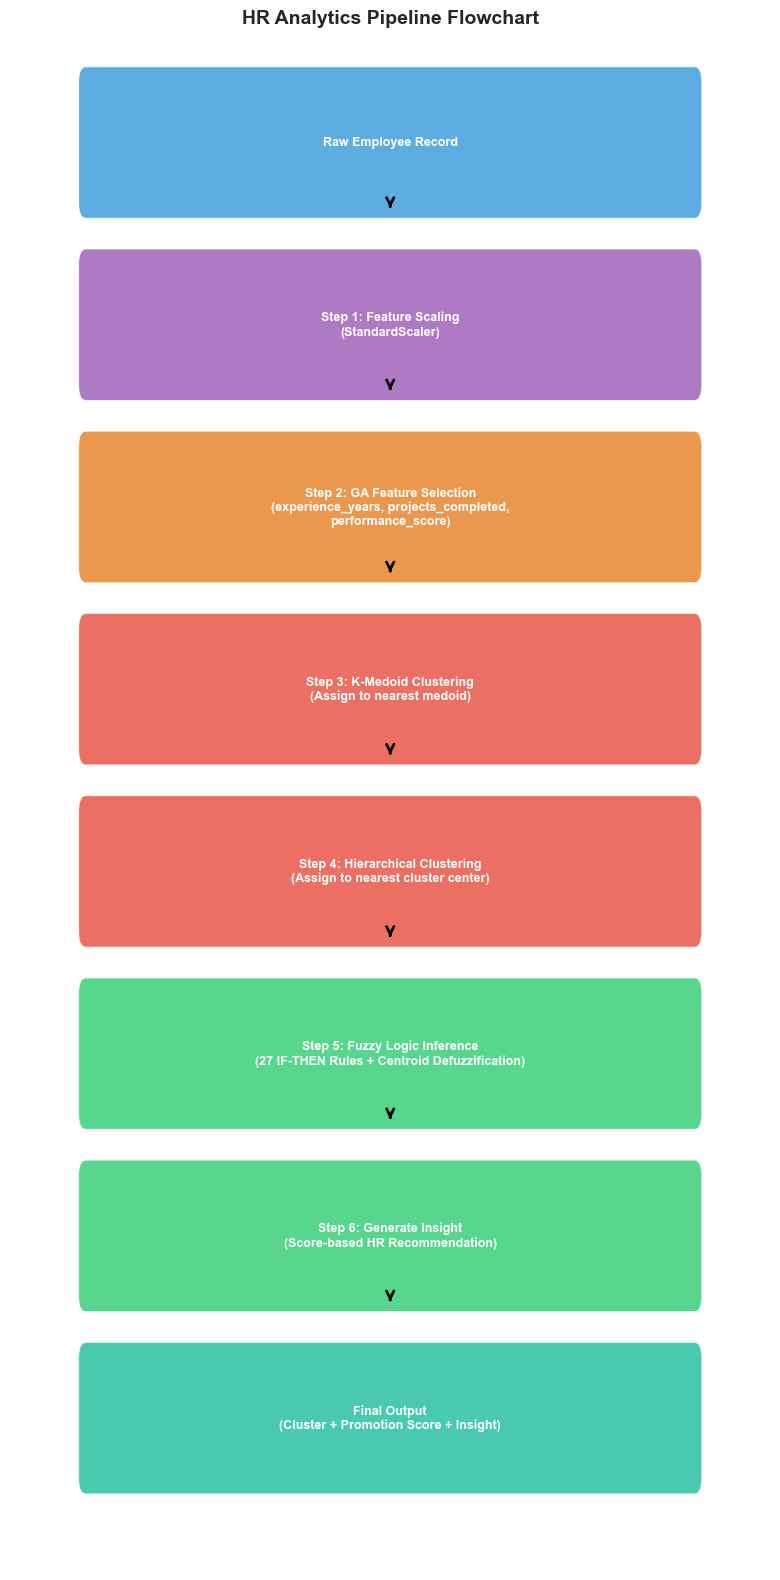

In [185]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8, 16))
ax.axis('off')

steps = [
    "Raw Employee Record",
    "Step 1: Feature Scaling\n(StandardScaler)",
    "Step 2: GA Feature Selection\n(experience_years, projects_completed,\nperformance_score)",
    "Step 3: K-Medoid Clustering\n(Assign to nearest medoid)",
    "Step 4: Hierarchical Clustering\n(Assign to nearest cluster center)",
    "Step 5: Fuzzy Logic Inference\n(27 IF-THEN Rules + Centroid Defuzzification)",
    "Step 6: Generate Insight\n(Score-based HR Recommendation)",
    "Final Output\n(Cluster + Promotion Score + Insight)"
]

colors = ['#3498db', '#9b59b6', '#e67e22', '#e74c3c', 
          '#e74c3c', '#2ecc71', '#2ecc71', '#1abc9c']

y = 0.95
for i, (step, color) in enumerate(zip(steps, colors)):
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.1, y - 0.05), 0.8, 0.08,
        boxstyle="round,pad=0.01",
        facecolor=color, alpha=0.8,
        transform=ax.transAxes))
    ax.text(0.5, y - 0.01, step,
            ha='center', va='center',
            fontsize=9, color='white',
            fontweight='bold',
            transform=ax.transAxes)
    if i < len(steps) - 1:
        ax.annotate('', 
                    xy=(0.5, y - 0.055),
                    xytext=(0.5, y - 0.05),
                    xycoords='axes fraction',
                    textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='black', lw=2))
    y -= 0.12

plt.title('HR Analytics Pipeline Flowchart', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()